<a href="https://colab.research.google.com/github/meghana2343/datascience/blob/main/GANs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**** GENERATIVE  MODELLING CASE STUDY: TYPES OF GANs****

STUDENT ID: 23070310

This is the second  assignment if module Advanced research module where  types of GANs are excuted

### Part 1 of GANs assignment ###

 part 1 includes of generating gans from the tutorial

In [1]:
# Import packages.
import torch
from torch import nn
import math
import matplotlib.pyplot as plt

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
# Setting a seed for reproducibility.
torch.manual_seed(42)

In [3]:
train_data_length = 1024
train_data = torch.zeros((train_data_length, 2))

train_data[:, 0] = 2.0 * math.pi * torch.rand(train_data_length)
train_data[:, 1] = torch.sin(train_data[:, 0])

train_labels = torch.zeros(train_data_length)
train_set = [(train_data[i], train_labels[i]) for i in range(train_data_length)]

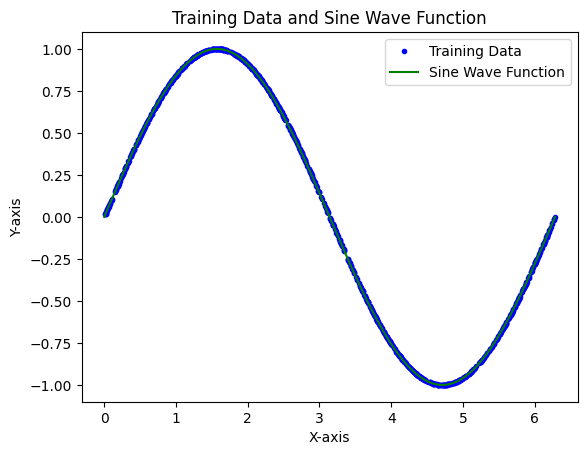

In [4]:
# Plot the training data
plt.plot(train_data[:, 0], train_data[:, 1], ".", color="blue", label="Training Data")

# Add a smooth sine wave for comparison
x_smooth = torch.linspace(0, 2 * math.pi, 500) # Generate x values from 0 to 2*pi
y_smooth = torch.sin(x_smooth) # Calculate sin(x)
plt.plot(x_smooth.numpy(), y_smooth.numpy(), "-", color="green", label="Sine Wave Function")

plt.title("Training Data and Sine Wave Function")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.show()

### Generate 2D Spiral Data

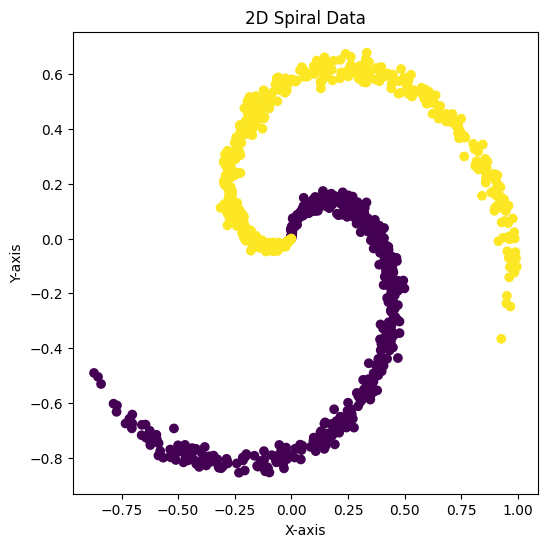

In [5]:
import numpy as np

def generate_spiral_data(num_samples=1000, noise=0.1, n_classes=2):
    X = np.zeros((num_samples, 2))
    y = np.zeros(num_samples, dtype='uint8')

    for i in range(n_classes):
        ix = range(num_samples // n_classes * i, num_samples // n_classes * (i + 1))
        r = np.linspace(0.0, 1, num_samples // n_classes) # radius
        t = np.linspace(i * 4, (i + 1) * 4, num_samples // n_classes) + np.random.randn(num_samples // n_classes) * noise # theta
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        y[ix] = i

    spiral_data = torch.from_numpy(X).float()
    spiral_labels = torch.from_numpy(y).float()
    return spiral_data, spiral_labels

spiral_data, spiral_labels = generate_spiral_data()

plt.figure(figsize=(6,6))
plt.scatter(spiral_data[:, 0], spiral_data[:, 1], c=spiral_labels, cmap='viridis')
plt.title("2D Spiral Data")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()


### Generate Mixture of Gaussians Data

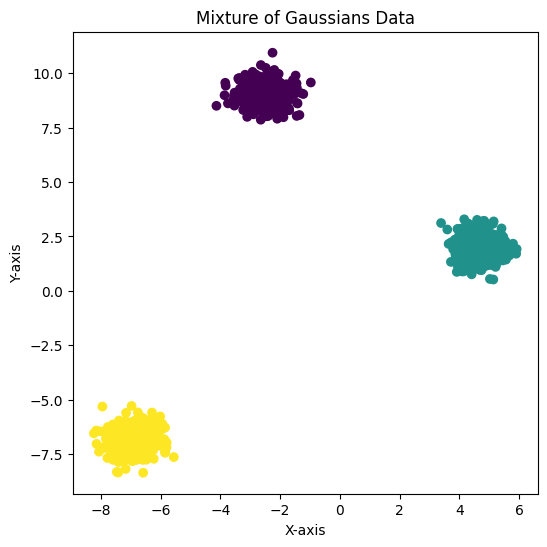

In [6]:
from sklearn.datasets import make_blobs

def generate_gaussian_mixture_data(num_samples=1000, n_centers=3, cluster_std=0.5):
    X, y = make_blobs(n_samples=num_samples, centers=n_centers, cluster_std=cluster_std, random_state=42)
    gaussian_data = torch.from_numpy(X).float()
    gaussian_labels = torch.from_numpy(y).float()
    return gaussian_data, gaussian_labels

gaussian_data, gaussian_labels = generate_gaussian_mixture_data()

plt.figure(figsize=(6,6))
plt.scatter(gaussian_data[:, 0], gaussian_data[:, 1], c=gaussian_labels, cmap='viridis')
plt.title("Mixture of Gaussians Data")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()


### Generate Noisy Parametric Data ($y = sin(2x) + 0.3cos(5x) + \epsilon$)

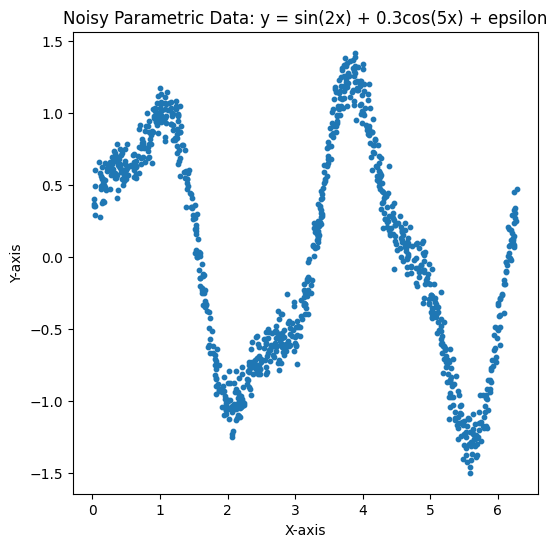

In [7]:
def generate_noisy_parametric_data(num_samples=1000, noise_std=0.1):
    x = torch.rand(num_samples, 1) * 2 * math.pi
    y = torch.sin(2 * x) + 0.3 * torch.cos(5 * x) + torch.randn(num_samples, 1) * noise_std
    noisy_parametric_data = torch.cat((x, y), dim=1)
    return noisy_parametric_data

noisy_parametric_data = generate_noisy_parametric_data()

plt.figure(figsize=(6,6))
plt.scatter(noisy_parametric_data[:, 0], noisy_parametric_data[:, 1], s=10)
plt.title("Noisy Parametric Data: y = sin(2x) + 0.3cos(5x) + epsilon")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()


In [8]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True
)

In [9]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),  # activation function
            nn.Dropout(0.3),  # dropout to prevent overfitting
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid(),  # sigmoid activation to produce a probability
        )

    # Describe how the forward pass is calculated.
    def forward(self, x):
        output = self.model(x)
        return output

In [10]:
# After declaring the discriminator class, we instantiate a discriminator object.
discriminator = Discriminator()
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
        )

    def forward(self, x):
        output = self.model(x)
        return output


# Instantiate generator object.
generator = Generator()

In [11]:
lr = 0.001
num_epochs = 2000
loss_function = nn.BCELoss()
optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(train_loader):
        # Data for training the discriminator.
        real_samples_labels = torch.ones((batch_size, 1))
        latent_space_samples = torch.randn((batch_size, 2))
        generated_samples = generator(latent_space_samples)
        generated_samples_labels = torch.zeros((batch_size, 1))
        all_samples = torch.cat((real_samples, generated_samples))
        all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))

        # Training the discriminator.
        discriminator.zero_grad()
        output_discriminator = discriminator(all_samples)
        loss_discriminator = loss_function(output_discriminator, all_samples_labels)
        loss_discriminator.backward()
        optimizer_discriminator.step()

        # Data for training the generator.
        latent_space_samples = torch.randn((batch_size, 2))

        # Training the generator.
        generator.zero_grad()
        generated_samples = generator(latent_space_samples)
        output_discriminator_generated = discriminator(generated_samples)
        loss_generator = loss_function(
            output_discriminator_generated, real_samples_labels
        )
        loss_generator.backward()
        optimizer_generator.step()

        # Print loss at various training stages.
        print_epoch_num = (
            100  # Change this depending on often the loss should be printed.
        )
        if epoch % print_epoch_num == 0 and n == batch_size - 1:
            print(f"Epoch: {epoch} Loss D.: {loss_discriminator}")
            print(f"Epoch: {epoch} Loss G.: {loss_generator}")

Epoch: 0 Loss D.: 0.10501156747341156
Epoch: 0 Loss G.: 2.9276413917541504
Epoch: 100 Loss D.: 0.703309178352356
Epoch: 100 Loss G.: 0.696789562702179
Epoch: 200 Loss D.: 0.670529305934906
Epoch: 200 Loss G.: 0.7512572407722473
Epoch: 300 Loss D.: 0.6841614246368408
Epoch: 300 Loss G.: 0.7553582191467285
Epoch: 400 Loss D.: 0.661787748336792
Epoch: 400 Loss G.: 0.7027472853660583
Epoch: 500 Loss D.: 0.7167990207672119
Epoch: 500 Loss G.: 0.699663519859314
Epoch: 600 Loss D.: 0.6691504716873169
Epoch: 600 Loss G.: 0.7459690570831299
Epoch: 700 Loss D.: 0.7161340117454529
Epoch: 700 Loss G.: 0.6971224546432495
Epoch: 800 Loss D.: 0.6681060791015625
Epoch: 800 Loss G.: 0.9564664363861084
Epoch: 900 Loss D.: 0.7163175344467163
Epoch: 900 Loss G.: 0.6832739114761353
Epoch: 1000 Loss D.: 0.6924228668212891
Epoch: 1000 Loss G.: 0.7288417816162109
Epoch: 1100 Loss D.: 0.600561261177063
Epoch: 1100 Loss G.: 1.2107648849487305
Epoch: 1200 Loss D.: 0.703054666519165
Epoch: 1200 Loss G.: 0.6751221

In [12]:
import torch

# Generate 1000 random 2D points and feed them to the generator.
latent_space_samples = torch.randn(1000, 2)
generated_samples = generator(latent_space_samples)

# Turn the PyTorch tensor into a NumPy array.
generated_samples_numpy = generated_samples.detach().numpy()

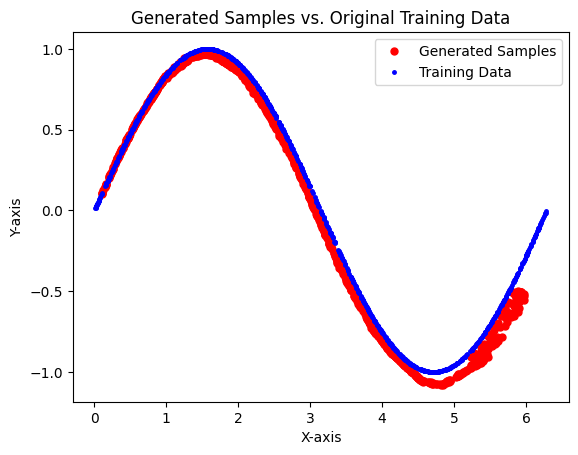

In [13]:
# Plot the generated samples and the original training data.
plt.plot(
    generated_samples_numpy[:, 0], generated_samples_numpy[:, 1], ".", markersize=10,
    label="Generated Samples", color="red"
)
plt.plot(train_data[:, 0], train_data[:, 1], ".", markersize=5, label="Training Data", color="blue")
plt.title("Generated Samples vs. Original Training Data")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.legend()
plt.show()

#### part 2 of the assignment

2.1: blood medmnist dataset

In [3]:
pip install medmnist torch torchvision matplotlib scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.0 MB/s eta 0:00:00


In [4]:
 # Load and explore BloodMNIST dataset


import medmnist
from medmnist import BloodMNIST, INFO
import torchvision.transforms as transforms # Added this line
import torch
from torch.utils.data import DataLoader

# Dataset info
info = INFO['bloodmnist']
print('BloodMNIST Info:')
print(f'  Task          : {info["task"]}')
print(f'  n_channels    : {info["n_channels"]}')
print(f'  n_classes     : {len(info["label"])}')   # ← fixed: count the label dict entries
print(f'  Labels        : {info["label"]}')

#  Image transforms: resize to 64×64, normalise to [-1, 1]
IMG_SIZE   = 64
transform_blood = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # → [-1, 1]
])

# Download and load training split
train_blood = BloodMNIST(split='train', transform=transform_blood, download=True)
test_blood  = BloodMNIST(split='test',  transform=transform_blood, download=True)

print(f'\nTraining samples: {len(train_blood)}')
print(f'Test samples    : {len(test_blood)}')

blood_loader = DataLoader(train_blood, batch_size=128, shuffle=True, num_workers=2, drop_last=True)

BloodMNIST Info:
  Task          : multi-class
  n_channels    : 3
  n_classes     : 8
  Labels        : {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}


100%|██████████| 35.5M/35.5M [00:03<00:00, 11.5MB/s]



Training samples: 11959
Test samples    : 3421


Text(0, 0.5, 'Count')

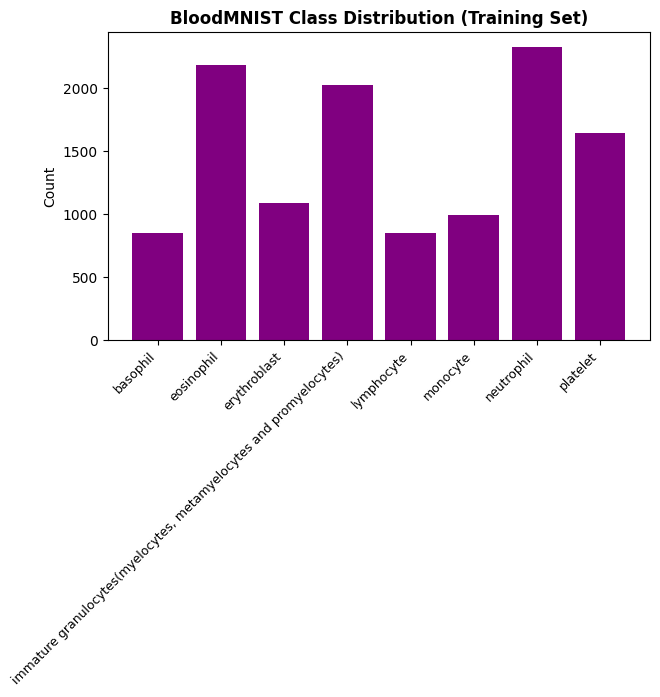

In [16]:
#Explore BloodMNIST — class distribution and sample images


import matplotlib.pyplot as plt
import numpy as np
from medmnist import INFO


info = INFO['bloodmnist']
class_names = list(info['label'].values())

# ── Extract labels
all_labels = [int(train_blood[i][1].item()) for i in range(len(train_blood))]
from collections import Counter
label_counts = Counter(all_labels)

fig, ax = plt.subplots(1, 1, figsize=(7, 4))



# Class distribution bar chart
ax.bar(range(len(class_names)),
            [label_counts[i] for i in range(len(class_names))],
            color='purple')
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
ax.set_title('BloodMNIST Class Distribution (Training Set)', fontweight='bold')
ax.set_ylabel('Count')

<Figure size 640x480 with 0 Axes>

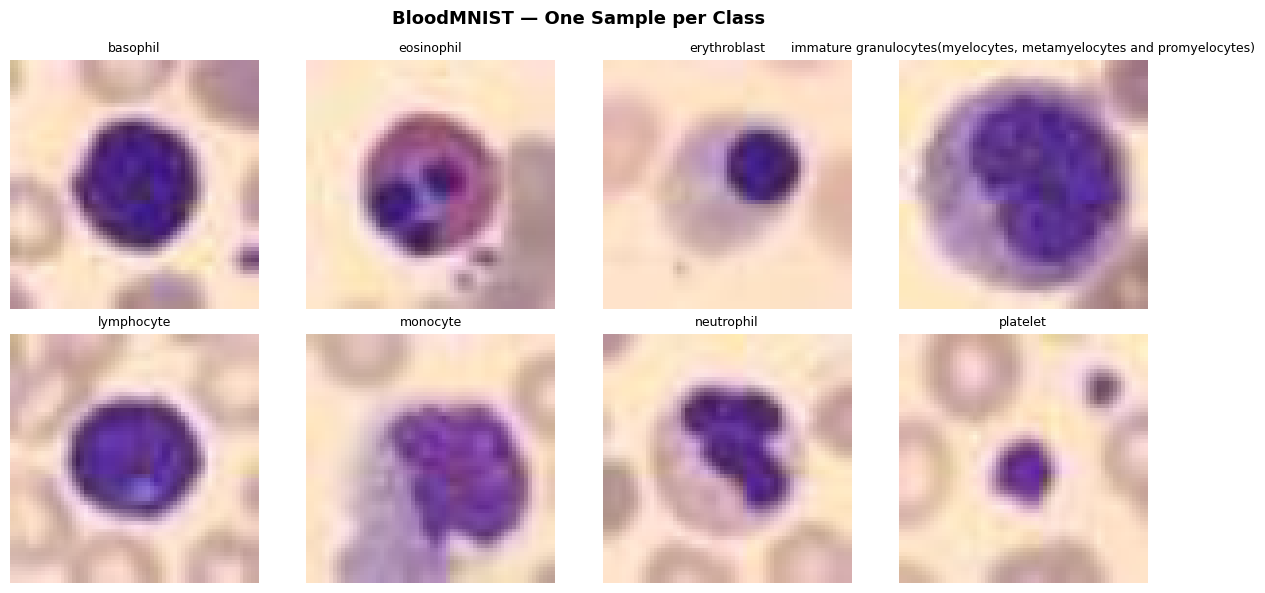

Class distribution explored.


In [17]:
# Sample images (one per class)
axes[1].axis('off')
plt.tight_layout()

# Show a grid of sample images from each class
fig2, sample_axes = plt.subplots(2, 4, figsize=(12, 6))
shown = set()
idx = 0
for i, (img, label) in enumerate(train_blood):
    lab = int(label.item())
    if lab not in shown:
        shown.add(lab)
        row, col = lab // 4, lab % 4
        # De-normalise: img ∈ [-1,1] → [0,1]
        img_np = (img.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
        sample_axes[row][col].imshow(img_np)
        sample_axes[row][col].set_title(class_names[lab], fontsize=9)
        sample_axes[row][col].axis('off')
    if len(shown) == len(class_names):
        break

fig2.suptitle('BloodMNIST — One Sample per Class', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('blood_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Class distribution explored.')

In [86]:
# ─DCGAN architecture for 64×64 RGB images
# Based on Radford et al. (2015): "Unsupervised Representation Learning with

from torch import nn
import torch

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Hyperparameters
LATENT_DIM  = 100     # size of latent noise vector
N_GEN_FEAT  = 64      # base feature map size for generator
N_DIS_FEAT  = 64      # base feature map size for discriminator
N_CHANNELS  = 3       # RGB


def weights_init(m):

    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class DCGenerator(nn.Module):

    def __init__(self, latent_dim=LATENT_DIM, ngf=N_GEN_FEAT, nc=N_CHANNELS):
        super().__init__()
        self.net = nn.Sequential(
            # Input: z → (ngf*8) × 4 × 4
            nn.ConvTranspose2d(latent_dim, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # (ngf*8) × 4 × 4 → (ngf*4) × 8 × 8
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # (ngf*4) × 8 × 8 → (ngf*2) × 16 × 16
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # (ngf*2) × 16 × 16 → ngf × 32 × 32
            nn.ConvTranspose2d(ngf * 2, ngf,     4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # ngf × 32 × 32 → nc × 64 × 64
            nn.ConvTranspose2d(ngf,     nc,      4, 2, 1, bias=False),
            nn.Tanh()                               # output ∈ [-1, 1]
        )

    def forward(self, z):
        return self.net(z)


class DCDiscriminator(nn.Module):
    """
    DCGAN Discriminator: maps a 64×64×3 image to a single probability.

    Architecture (spatial size at each stage):
        3×64×64 → 64×32×32 → 128×16×16 → 256×8×8 → 512×4×4 → 1

    Uses strided Conv2d to downsample (no pooling layers),
    LeakyReLU(0.2) as recommended for discriminators, Sigmoid at output.
    """
    def __init__(self, ndf=N_DIS_FEAT, nc=N_CHANNELS):
        super().__init__()
        self.net = nn.Sequential(
            # nc × 64 × 64 → ndf × 32 × 32 (no BatchNorm on first layer)
            nn.Conv2d(nc,      ndf,     4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # ndf × 32 × 32 → (ndf*2) × 16 × 16
            nn.Conv2d(ndf,     ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*2) × 16 × 16 → (ndf*4) × 8 × 8
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*4) × 8 × 8 → (ndf*8) × 4 × 4
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*8) × 4 × 4 → 1 × 1 × 1
            nn.Conv2d(ndf * 8, 1,       4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)  # flatten to (batch, 1)


#  Instantiate and initialise
netG_blood = DCGenerator().to(DEVICE)
netD_blood = DCDiscriminator().to(DEVICE)
netG_blood.apply(weights_init)
netD_blood.apply(weights_init)

print('Generator architecture:')
print(netG_blood)
print(f'\nGenerator parameters  : {sum(p.numel() for p in netG_blood.parameters()):,}')
print(f'Discriminator params  : {sum(p.numel() for p in netD_blood.parameters()):,}')

Generator architecture:
DCGenerator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False

In [23]:
#
#DCGAN training on BloodMNIST
import torch

def train_dcgan(
    netG, netD,
    dataloader,
    n_epochs:   int   = 50,
    lr:         float = 2e-4,
    latent_dim: int   = 100,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
):
    """
    Train a DCGAN (Generator + Discriminator) on an image dataset.

    Uses Binary Cross-Entropy loss with label smoothing.
    Fixed noise vector is used to track visual progress across epochs.

    Args:
        netG, netD  : Instantiated generator / discriminator.
        dataloader  : PyTorch DataLoader yielding (image, label) batches.
        n_epochs    : Training epochs.
        lr          : Adam learning rate.
        latent_dim  : Latent vector dimension.
        device      : torch.device.

    Returns:
        g_losses (list), d_losses (list), img_snapshots (list of tensors)
    """
    criterion = nn.BCELoss()
    opt_G = optim.Adam(netG.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = optim.Adam(netD.parameters(), lr=lr, betas=(0.5, 0.999))

    # Fixed noise for visual monitoring throughout training
    fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)

    g_losses, d_losses, img_snapshots = [], [], []

    for epoch in range(1, n_epochs + 1):
        g_ep, d_ep, n_b = 0.0, 0.0, 0

        for real_imgs, _ in dataloader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)

            real_labels = torch.ones(bs,  1, device=device) * 0.9
            fake_labels = torch.zeros(bs, 1, device=device)

            # ── Train Discriminator
            opt_D.zero_grad()
            d_real = criterion(netD(real_imgs), real_labels)
            z = torch.randn(bs, latent_dim, 1, 1, device=device)
            fake_imgs = netG(z).detach()
            d_fake    = criterion(netD(fake_imgs), fake_labels)
            d_loss    = (d_real + d_fake) / 2
            d_loss.backward()
            opt_D.step()

            # ── Train Generator
            opt_G.zero_grad()
            z = torch.randn(bs, latent_dim, 1, 1, device=device)
            gen = netG(z)
            g_loss = criterion(netD(gen), real_labels)
            g_loss.backward()
            opt_G.step()

            g_ep += g_loss.item(); d_ep += d_loss.item(); n_b += 1

        g_losses.append(g_ep / n_b)
        d_losses.append(d_ep / n_b)

        # ── Snapshot every 10 epochs
        if epoch % 10 == 0 or epoch == 1:
            netG.eval()
            with torch.no_grad():
                snap = netG(fixed_noise).detach().cpu()
            img_snapshots.append((epoch, snap))
            netG.train()
            print(f'Epoch {epoch:3d}/{n_epochs} | G: {g_losses[-1]:.4f} | D: {d_losses[-1]:.4f}')

    return g_losses, d_losses, img_snapshots


# ── Train the BloodMNIST DCGAN
BLOOD_EPOCHS = 50
print(f'Training BloodMNIST DCGAN for {BLOOD_EPOCHS} epochs...')
g_loss_blood, d_loss_blood, blood_snaps = train_dcgan(
    netG_blood, netD_blood,
    blood_loader,
    n_epochs=BLOOD_EPOCHS,
    lr=2e-4,
    latent_dim=LATENT_DIM
)

Training BloodMNIST DCGAN for 50 epochs...
Epoch   1/50 | G: 2.3547 | D: 0.5472
Epoch  10/50 | G: 2.1460 | D: 0.4700
Epoch  20/50 | G: 2.3380 | D: 0.3962
Epoch  30/50 | G: 2.6290 | D: 0.3128
Epoch  40/50 | G: 3.3700 | D: 0.2782
Epoch  50/50 | G: 3.3866 | D: 0.2257


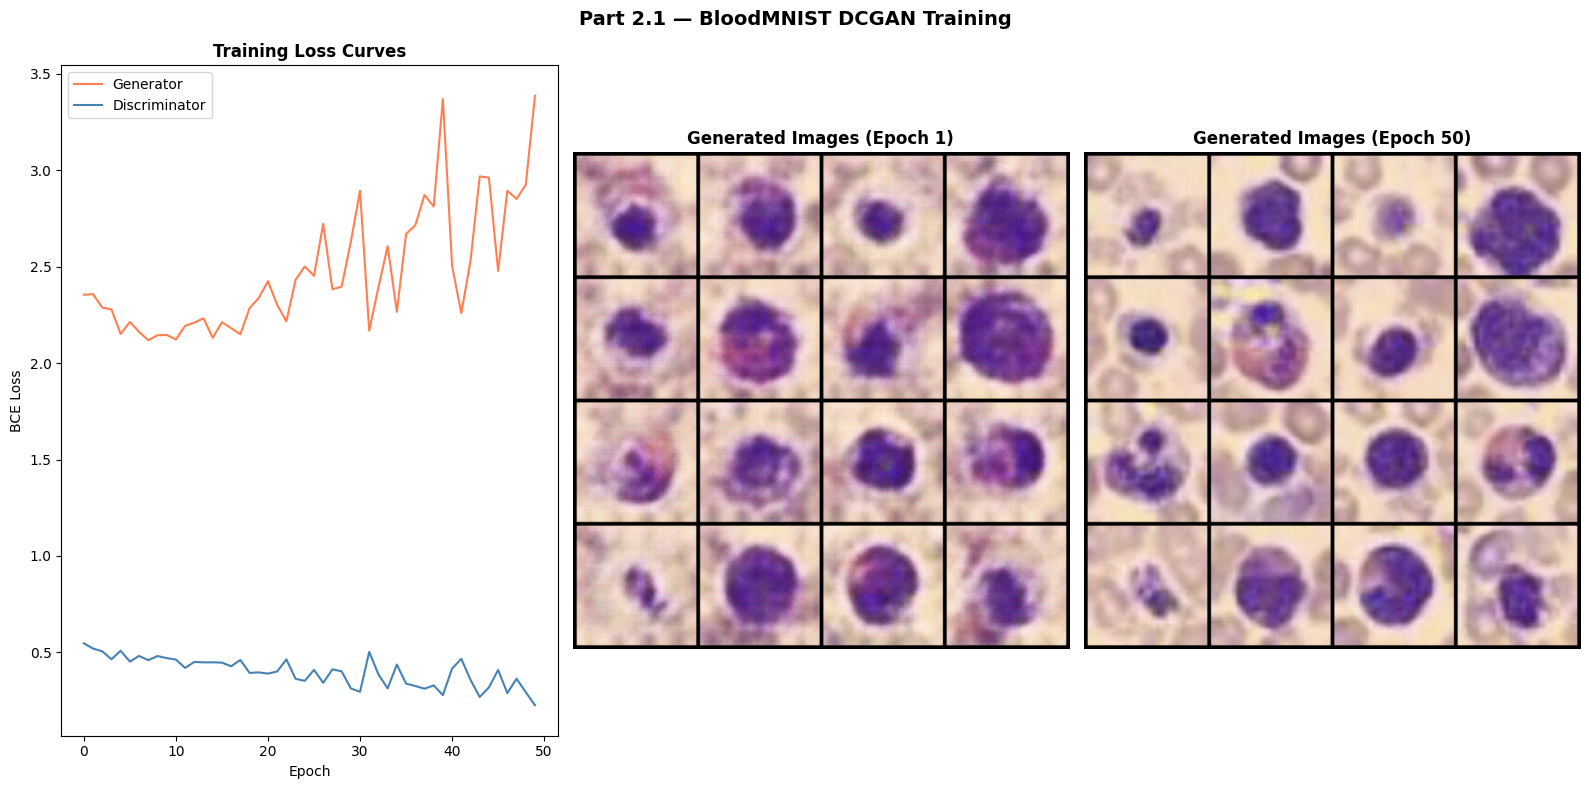

In [25]:

#  Visualise generated blood cell images and training curves
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec # Import gridspec
import torchvision.utils as vutils # Import vutils
import numpy as np # Import numpy

def show_dcgan_results(g_losses, d_losses, snapshots, title='DCGAN Results',
                       save_name=None):

    fig = plt.figure(figsize=(16, 8))
    gs  = gridspec.GridSpec(2, 3, figure=fig)

    # ── Loss curves
    ax_loss = fig.add_subplot(gs[:, 0])
    ax_loss.plot(g_losses, label='Generator',     color='coral')
    ax_loss.plot(d_losses, label='Discriminator', color='steelblue')
    ax_loss.set_title('Training Loss Curves', fontweight='bold')
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('BCE Loss')
    ax_loss.legend()

    # ── Image grids: first and last snapshot
    snap_epochs = [snapshots[0], snapshots[-1]]
    snap_titles = ['Generated Images (Epoch 1)', f'Generated Images (Epoch {snap_epochs[1][0]})']

    for col, ((ep, imgs), ttl) in enumerate(zip(snap_epochs, snap_titles)):
        grid = vutils.make_grid(imgs[:16], nrow=4, normalize=True, value_range=(-1, 1))
        np_grid = grid.permute(1, 2, 0).numpy().clip(0, 1)
        ax = fig.add_subplot(gs[:, col + 1])
        ax.imshow(np_grid)
        ax.set_title(ttl, fontweight='bold')
        ax.axis('off')

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()


show_dcgan_results(g_loss_blood, d_loss_blood, blood_snaps,
                   title='Part 2.1 — BloodMNIST DCGAN Training',
                   save_name='blood_dcgan_results.png')

In [28]:
import numpy as np
from scipy.linalg import sqrtm
import torchvision.transforms as transforms # Ensure transforms is imported
from torchvision.models import inception_v3, Inception_V3_Weights # Import Inception_V3_Weights

#  Real vs. generated comparison and FID score
# Fréchet Inception Distance (FID) measures the distance between the
# real and generated image distributions in Inception feature space.
# Lower FID = more realistic generated images.


def compute_fid_features(images_tensor, device=DEVICE):

    # Load Inception v3 (pretrained) and remove classification head
    # Use 'weights' argument instead of 'pretrained' to address deprecation warning
    inception = inception_v3(weights=Inception_V3_Weights.DEFAULT, transform_input=False).to(device)
    inception.fc = nn.Identity()   # return 2048-dim features
    inception.eval()

    # Resize images to 299×299 (Inception input size)
    resize = transforms.Resize((299, 299), antialias=True)

    features = []
    BATCH = 64
    with torch.no_grad():
        for i in range(0, images_tensor.size(0), BATCH):
            batch = resize(images_tensor[i:i+BATCH].to(device))
            feat  = inception(batch)
            features.append(feat.cpu().numpy())

    return np.concatenate(features, axis=0)


def fid_score(real_feats: np.ndarray, fake_feats: np.ndarray) -> float:

    mu1, sigma1 = real_feats.mean(0), np.cov(real_feats, rowvar=False)
    mu2, sigma2 = fake_feats.mean(0), np.cov(fake_feats, rowvar=False)

    diff  = mu1 - mu2
    # Remove 'disp=False' to address deprecation warning
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean):   # numerical artefact — take real part
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return float(fid)


#  Collect real images and generate fake images
print('Collecting real images for FID...')
real_imgs_list = []
for imgs, _ in blood_loader:
    real_imgs_list.append(imgs)
    if len(real_imgs_list) * blood_loader.batch_size >= 1000:
        break
real_imgs_fid = torch.cat(real_imgs_list, dim=0)[:1000]

print('Generating fake images...')
netG_blood.eval()
with torch.no_grad():
    z_fid = torch.randn(1000, LATENT_DIM, 1, 1, device=DEVICE)
    fake_imgs_fid = netG_blood(z_fid).cpu()

#  Compute FID
print('Computing FID (this may take a moment)...')
real_feats = compute_fid_features(real_imgs_fid)
fake_feats = compute_fid_features(fake_imgs_fid)
fid = fid_score(real_feats, fake_feats)
print(f'\n>>> BloodMNIST DCGAN — Fréchet Inception Distance (FID): {fid:.2f}')
print('    (Lower FID = more realistic generated images)')

Generating fake images...
Computing FID (this may take a moment)...

>>> BloodMNIST DCGAN — Fréchet Inception Distance (FID): 90.02
    (Lower FID = more realistic generated images)


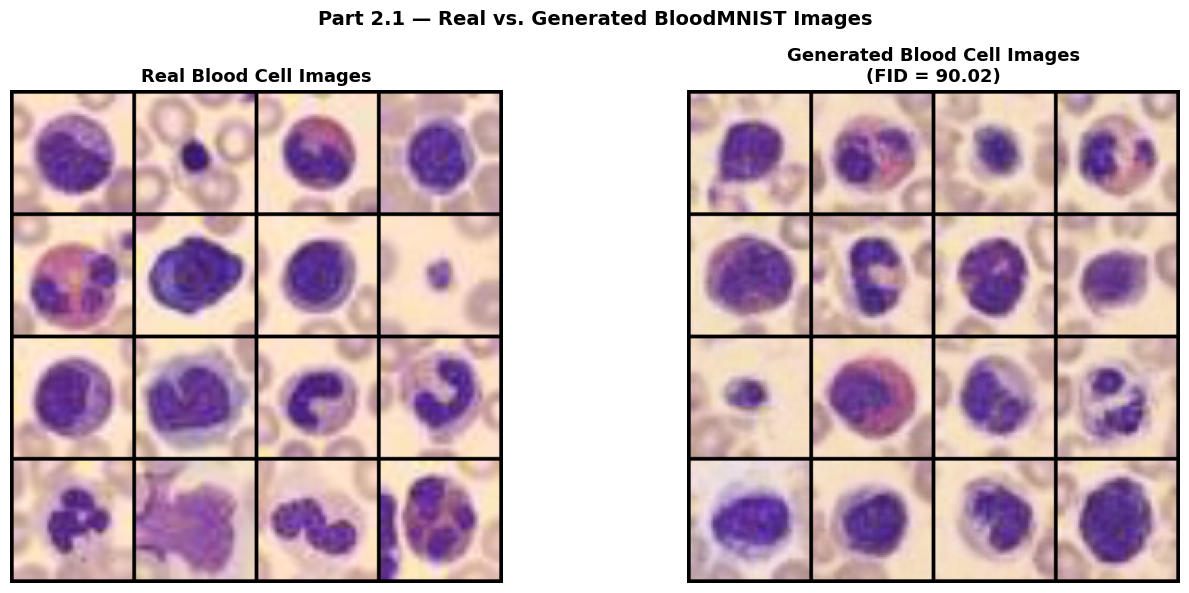

In [29]:
#
#  Side-by-side real vs. generated blood cell images


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Real images
real_grid = vutils.make_grid(real_imgs_fid[:16], nrow=4, normalize=True, value_range=(-1, 1))
axes[0].imshow(real_grid.permute(1, 2, 0).numpy().clip(0, 1))
axes[0].set_title('Real Blood Cell Images', fontweight='bold', fontsize=13)
axes[0].axis('off')

# Fake images
fake_grid = vutils.make_grid(fake_imgs_fid[:16], nrow=4, normalize=True, value_range=(-1, 1))
axes[1].imshow(fake_grid.permute(1, 2, 0).numpy().clip(0, 1))
axes[1].set_title(f'Generated Blood Cell Images\n(FID = {fid:.2f})', fontweight='bold', fontsize=13)
axes[1].axis('off')

plt.suptitle('Part 2.1 — Real vs. Generated BloodMNIST Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('blood_real_vs_fake.png', dpi=150, bbox_inches='tight')
plt.show()

2.2:

In [42]:
#Load and explore CICIDS 2017 — Wednesday file
# Upload the file to Colab or mount Drive, then set FILE_PATH accordingly.



FILE_PATH = '/content/Wednesday-workingHours.pcap_ISCX.csv'

# ── Load
df = pd.read_csv(FILE_PATH, low_memory=False)
df.columns = df.columns.str.strip()   # remove accidental whitespace

print(f'Shape: {df.shape}')
print(f'\nLabel distribution:')
print(df['Label'].value_counts())

Shape: (692703, 79)

Label distribution:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


### Preprocessing CICIDS 2017 Wednesday Data

Rows after filtering: 692692
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64

Feature dimensions : 78
Class balance       : 440031 BENIGN | 252661 DoS


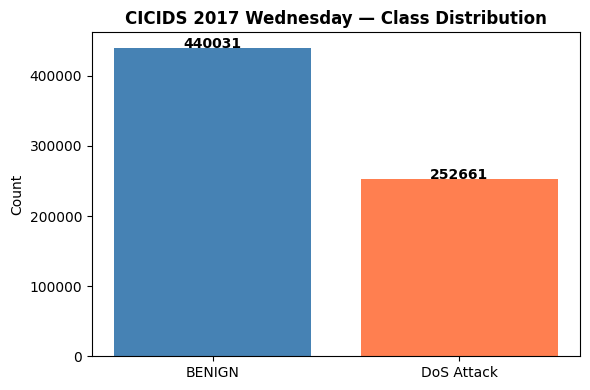

In [43]:
#
# Preprocess CICIDS — keep BENIGN + DoS only, clean and normalise
#

def preprocess_cicids(df: pd.DataFrame):
    """
    Preprocess the CICIDS 2017 Wednesday dataframe:
      1. Keep only BENIGN and DoS attack rows.
      2. Drop non-numeric and identifier columns.
      3. Replace Inf/NaN values.
      4. Standardise features to zero mean and unit variance.

    Args:
        df: Raw pandas DataFrame.

    Returns:
        X_scaled (np.ndarray), y (np.ndarray), feature_names (list)
    """
    # Keep BENIGN and any row whose label contains 'DoS'
    mask = df['Label'].str.contains('BENIGN|DoS', case=False, na=False)
    df   = df[mask].copy()
    print(f'Rows after filtering: {len(df)}')
    print(df['Label'].value_counts())

    # Extract labels
    y = (df['Label'] != 'BENIGN').astype(int).values   # 0=benign, 1=attack

    # Drop non-feature columns
    drop_cols = ['Label', 'Flow ID', ' Source IP', ' Source Port',
                 ' Destination IP', ' Destination Port', ' Timestamp']
    drop_cols = [c for c in drop_cols if c in df.columns]
    X = df.drop(columns=drop_cols)

    # Keep only numeric columns
    X = X.select_dtypes(include=[np.number])

    # Replace Inf and NaN
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)

    feature_names = X.columns.tolist()

    # Standardise
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32)

    return X_scaled, y, feature_names


X_cicids, y_cicids, feature_names = preprocess_cicids(df)
N_FEATURES = X_cicids.shape[1]
print(f'\nFeature dimensions : {N_FEATURES}')
print(f'Class balance       : {(y_cicids==0).sum()} BENIGN | {(y_cicids==1).sum()} DoS')

# ── Class distribution plot
fig, ax = plt.subplots(figsize=(6, 4))
classes, counts = np.unique(y_cicids, return_counts=True)
ax.bar(['BENIGN', 'DoS Attack'], counts, color=['steelblue', 'coral'])
ax.set_title('CICIDS 2017 Wednesday — Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate(counts):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('cicids_class_dist.png', dpi=150)
plt.show()

Rows after filtering: 692692
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64

Feature dimensions : 78
Class balance       : 440031 BENIGN | 252661 DoS


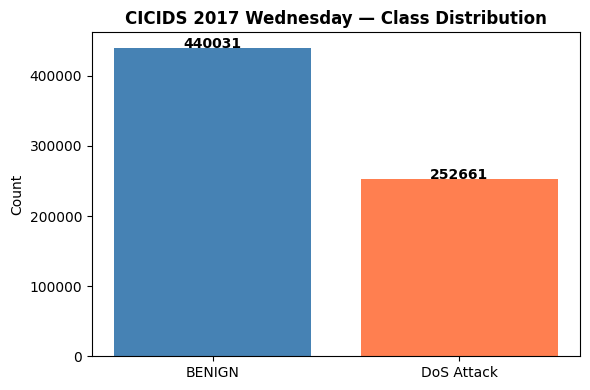

In [44]:
def preprocess_cicids(df: pd.DataFrame):

    # Keep BENIGN and any row whose label contains 'DoS'
    mask = df['Label'].str.contains('BENIGN|DoS', case=False, na=False)
    df   = df[mask].copy()
    print(f'Rows after filtering: {len(df)}')
    print(df['Label'].value_counts())

    # Extract labels
    y = (df['Label'] != 'BENIGN').astype(int).values   # 0=benign, 1=attack

    # Drop non-feature columns
    drop_cols = ['Label', 'Flow ID', ' Source IP', ' Source Port',
                 ' Destination IP', ' Destination Port', ' Timestamp']
    drop_cols = [c for c in drop_cols if c in df.columns]
    X = df.drop(columns=drop_cols)

    # Keep only numeric columns
    X = X.select_dtypes(include=[np.number])

    # Replace Inf and NaN
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)

    feature_names = X.columns.tolist()

    # Standardise
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32)

    return X_scaled, y, feature_names


X_cicids, y_cicids, feature_names = preprocess_cicids(df)
N_FEATURES = X_cicids.shape[1]
print(f'\nFeature dimensions : {N_FEATURES}')
print(f'Class balance       : {(y_cicids==0).sum()} BENIGN | {(y_cicids==1).sum()} DoS')

# ── Class distribution plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
classes, counts = np.unique(y_cicids, return_counts=True)
ax.bar(['BENIGN', 'DoS Attack'], counts, color=['steelblue', 'coral'])
ax.set_title('CICIDS 2017 Wednesday — Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate(counts):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('cicids_class_dist.png', dpi=150)
plt.show()

### Tabular GAN Model Definitions

In [45]:
class TabularGenerator(nn.Module):
    def __init__(self, latent_dim: int, output_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim),
            nn.Tanh() # Tanh to output values between -1 and 1, consistent with StandardScaler normalization
        )

    def forward(self, z):
        return self.net(z)


class TabularDiscriminator(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

print('TabularGenerator and TabularDiscriminator classes defined.')

TabularGenerator and TabularDiscriminator classes defined.


### Tabular GAN Training Function

In [48]:
from torch.utils.data import TensorDataset, DataLoader

def train_tabular_gan(
    X: torch.Tensor,
    noise_dim: int,
    n_epochs: int = 100,
    batch_size: int = 64,
    lr: float = 0.0002,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
):
    dataset = TensorDataset(X)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    generator = TabularGenerator(latent_dim=noise_dim, output_dim=X.shape[1]).to(device)
    discriminator = TabularDiscriminator(input_dim=X.shape[1]).to(device)

    criterion = nn.BCELoss()
    optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    g_losses, d_losses = [], []

    print(f'Starting Tabular GAN training for {n_epochs} epochs...')
    for epoch in range(n_epochs):
        for i, (real_data,) in enumerate(dataloader):
            real_data = real_data.to(device)
            current_batch_size = real_data.size(0);

            # Labels for real and fake data
            real_labels = torch.ones(current_batch_size, 1).to(device) * 0.9 # Smooth labeling
            fake_labels = torch.zeros(current_batch_size, 1).to(device)

            # --- Train Discriminator ---
            optimizer_D.zero_grad()

            # Train with real data
            output_real = discriminator(real_data)
            loss_D_real = criterion(output_real, real_labels)
            loss_D_real.backward()

            # Train with fake data
            noise = torch.randn(current_batch_size, noise_dim).to(device)
            fake_data = generator(noise).detach() # Detach to prevent gradients from flowing to G
            output_fake = discriminator(fake_data)
            loss_D_fake = criterion(output_fake, fake_labels)
            loss_D_fake.backward()

            # Combine losses and update D
            loss_D = loss_D_real + loss_D_fake
            optimizer_D.step()

            # --- Train Generator ---
            optimizer_G.zero_grad()

            noise = torch.randn(current_batch_size, noise_dim).to(device)
            generated_data = generator(noise)
            output_generated = discriminator(generated_data)
            loss_G = criterion(output_generated, real_labels) # G tries to fool D
            loss_G.backward()
            optimizer_G.step()

        g_losses.append(loss_G.item())
        d_losses.append(loss_D.item())

        if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == n_epochs - 1:
            print(f'Epoch [{epoch+1}/{n_epochs}], D Loss: {loss_D.item():.4f}, G Loss: {loss_G.item():.4f}')

    print('Tabular GAN training complete!')
    return generator, g_losses, d_losses

print('train_tabular_gan function defined.')

train_tabular_gan function defined.


### Training the Tabular GAN on CICIDS 2017 Wednesday Data

Starting Tabular GAN training for 300 epochs...
Epoch [1/300], D Loss: 0.7459, G Loss: 1.6768
Epoch [10/300], D Loss: 0.4335, G Loss: 3.5498
Epoch [20/300], D Loss: 0.6737, G Loss: 2.3078
Epoch [30/300], D Loss: 0.6338, G Loss: 2.1439
Epoch [40/300], D Loss: 0.6064, G Loss: 2.3641
Epoch [50/300], D Loss: 0.5794, G Loss: 2.7588
Epoch [60/300], D Loss: 0.6125, G Loss: 2.6148
Epoch [70/300], D Loss: 0.6134, G Loss: 2.5788
Epoch [80/300], D Loss: 0.5316, G Loss: 2.6780
Epoch [90/300], D Loss: 0.5709, G Loss: 2.6413
Epoch [100/300], D Loss: 0.5379, G Loss: 2.7560
Epoch [110/300], D Loss: 0.5445, G Loss: 2.7027
Epoch [120/300], D Loss: 0.5566, G Loss: 2.8698
Epoch [130/300], D Loss: 0.5706, G Loss: 2.7822
Epoch [140/300], D Loss: 0.5660, G Loss: 2.8163
Epoch [150/300], D Loss: 0.5378, G Loss: 2.9165
Epoch [160/300], D Loss: 0.5541, G Loss: 2.8876
Epoch [170/300], D Loss: 0.5373, G Loss: 2.8970
Epoch [180/300], D Loss: 0.5432, G Loss: 2.9373
Epoch [190/300], D Loss: 0.5968, G Loss: 2.6776
Epo

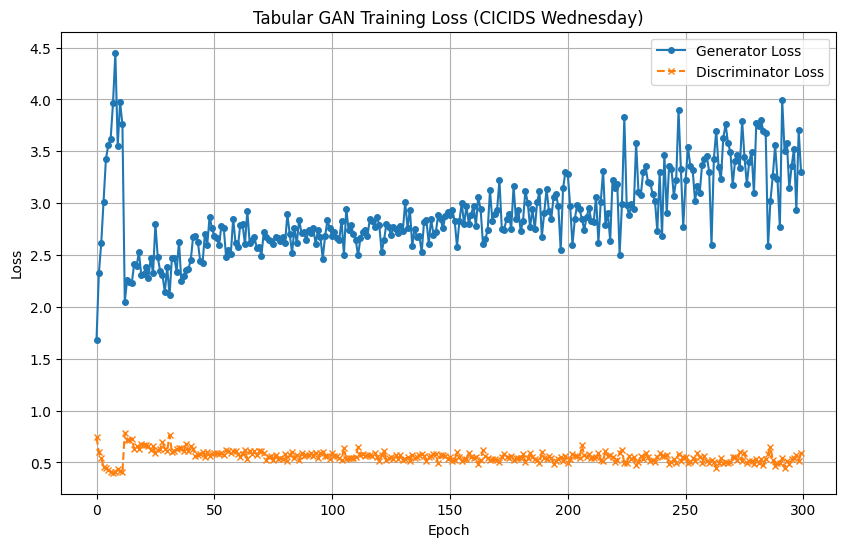

In [50]:
# Define hyperparameters
LATENT_DIM_CICIDS = 64 # Latent dimension for the generator's input noise
N_EPOCHS_CICIDS = 300 # Number of training epochs
BATCH_SIZE_CICIDS = 512 # Batch size for training
LEARNING_RATE_CICIDS = 0.0002 # Learning rate for Adam optimizers

# Instantiate device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Convert X_cicids to a PyTorch tensor
X_cicids_tensor = torch.from_numpy(X_cicids).float()

# Train the Tabular GAN
G_cicids, g_loss_cicids, d_loss_cicids = train_tabular_gan(
    X=X_cicids_tensor,
    noise_dim=LATENT_DIM_CICIDS,
    n_epochs=N_EPOCHS_CICIDS,
    batch_size=BATCH_SIZE_CICIDS,
    lr=LEARNING_RATE_CICIDS,
    device=device
)

# Plot training losses
plt.figure(figsize=(10,6))
plt.plot(g_loss_cicids, label="Generator Loss", linestyle='-', marker='o', markersize=4)
plt.plot(d_loss_cicids, label="Discriminator Loss", linestyle='--', marker='x', markersize=4)
plt.title("Tabular GAN Training Loss (CICIDS Wednesday)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Quantitative Evaluation: Mean Squared Error (MSE) of Feature Means

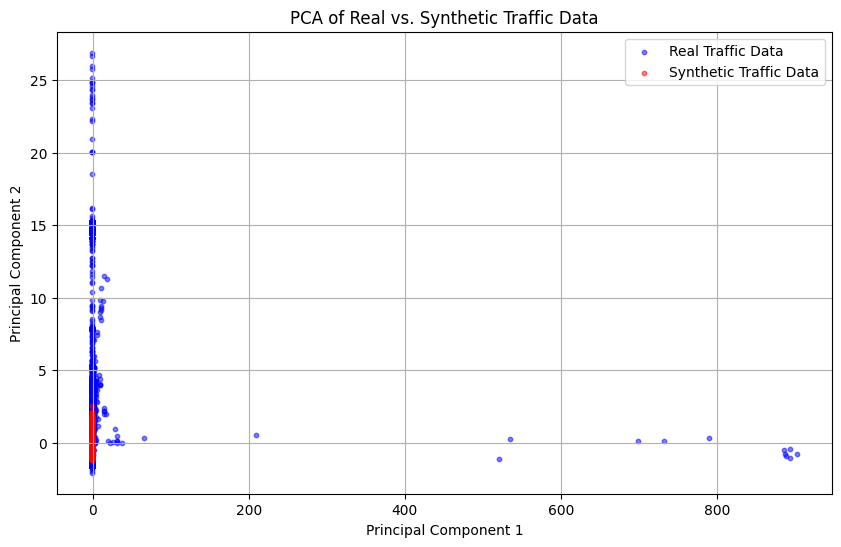

In [51]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Generate fake samples from the GAN
G_cicids.eval() # Set generator to evaluation mode
N_SAMPLES = 10000 # Number of samples to generate
noise = torch.randn(N_SAMPLES, 64).to(DEVICE) # latent_dim needs to be 64, not LATENT_DIM (which is 100)
synthetic_samples = G_cicids(noise).detach().cpu().numpy()

# Prepare real data subset
# Ensure X_cicids is numpy array
if isinstance(X_cicids, torch.Tensor):
    real_samples_subset = X_cicids[:N_SAMPLES].cpu().numpy()
else:
    real_samples_subset = X_cicids[:N_SAMPLES]

# --- PCA --- (already present, ensuring it runs after GAN training)
combined_data_pca = np.vstack([real_samples_subset, synthetic_samples])

# Use PCA for dimensionality reduction
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(combined_data_pca)

real_pca = pca_result[:N_SAMPLES]
synthetic_pca = pca_result[N_SAMPLES:]

plt.figure(figsize=(10, 6))
plt.scatter(real_pca[:, 0], real_pca[:, 1], alpha=0.5, s=10, label='Real Traffic Data', color='blue')
plt.scatter(synthetic_pca[:, 0], synthetic_pca[:, 1], alpha=0.5, s=10, label='Synthetic Traffic Data', color='red')
plt.title('PCA of Real vs. Synthetic Traffic Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


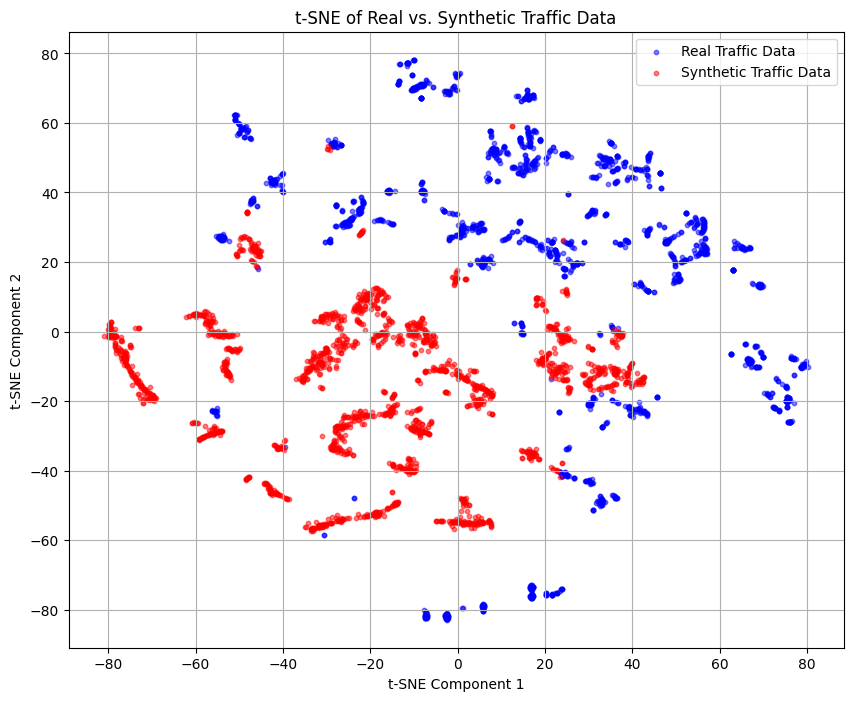

In [52]:
TSNE_SAMPLES = 2000 # Use a smaller number of samples for t-SNE due to computational cost

# Generate synthetic samples using the trained generator
G_cicids.eval() # Set generator to evaluation mode
noise_tsne = torch.randn(TSNE_SAMPLES, 64).to(DEVICE) # latent_dim needs to be 64
synthetic_samples_tsne = G_cicids(noise_tsne).detach().cpu().numpy()

# Prepare real data subset for t-SNE
# Use a subset of real data equal to the number of synthetic samples for balanced comparison
num_real_samples_tsne = min(TSNE_SAMPLES, X_cicids.shape[0])
real_samples_subset_tsne = X_cicids[:num_real_samples_tsne]

# Combine real and synthetic data for t-SNE
combined_data_tsne = np.vstack((real_samples_subset_tsne, synthetic_samples_tsne))

# Apply t-SNE (adjust perplexity and n_iter as needed)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, learning_rate=200)
reduced_data_tsne = tsne.fit_transform(combined_data_tsne)

# Split back into real and synthetic for plotting
real_tsne = reduced_data_tsne[:num_real_samples_tsne]
synthetic_tsne = reduced_data_tsne[num_real_samples_tsne:]

# Plot t-SNE results
plt.figure(figsize=(10, 8))
plt.scatter(real_tsne[:, 0], real_tsne[:, 1], alpha=0.5, s=10, label='Real Traffic Data', color='blue')
plt.scatter(synthetic_tsne[:, 0], synthetic_tsne[:, 1], alpha=0.5, s=10, label='Synthetic Traffic Data', color='red')
plt.title('t-SNE of Real vs. Synthetic Traffic Data')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.grid(True)
plt.show()

In [53]:
real_data_mean = np.mean(real_samples_subset, axis=0)
fake_data_mean = np.mean(synthetic_samples, axis=0)

mse = np.mean((real_data_mean - fake_data_mean)**2)

print(f"Mean Squared Error between real and synthetic feature means: {mse:.4f}")

Mean Squared Error between real and synthetic feature means: 0.1407


### Quantitative Evaluation: Mean Squared Error (MSE) of Feature Means



### Extending to Full CICIDS 2017 Dataset (All Days)



In [56]:
from sklearn.preprocessing import LabelEncoder

# Define the base path for CICIDS 2017 files (assuming they are in /content/)
# We'll include all days if available. Adjust paths if necessary.
CICIDS_FILE_PATHS = [

    '/content/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',

]

# Load all CICIDS 2017 files and concatenate them
full_df_list = []
for file_path in CICIDS_FILE_PATHS:
    if os.path.exists(file_path):
        df_day = pd.read_csv(file_path, low_memory=False)
        df_day.columns = df_day.columns.str.strip()  # Clean column names
        full_df_list.append(df_day)
    else:
        print(f"Warning: File not found: {file_path}. Skipping.")

if not full_df_list:
    raise FileNotFoundError("No CICIDS 2017 files found. Please ensure they are in the specified paths.")

full_cicids_df = pd.concat(full_df_list, ignore_index=True)

print(f'Full dataset shape: {full_cicids_df.shape}')
print(f'\nLabel distribution (Raw):')
print(full_cicids_df['Label'].value_counts())


Full dataset shape: (288602, 79)

Label distribution (Raw):
Label
BENIGN          288566
Infiltration        36
Name: count, dtype: int64



Preprocessed Full CICIDS dataset:
Feature dimensions : 78
Class balance (encoded):
BENIGN: 288566
Infiltration: 36


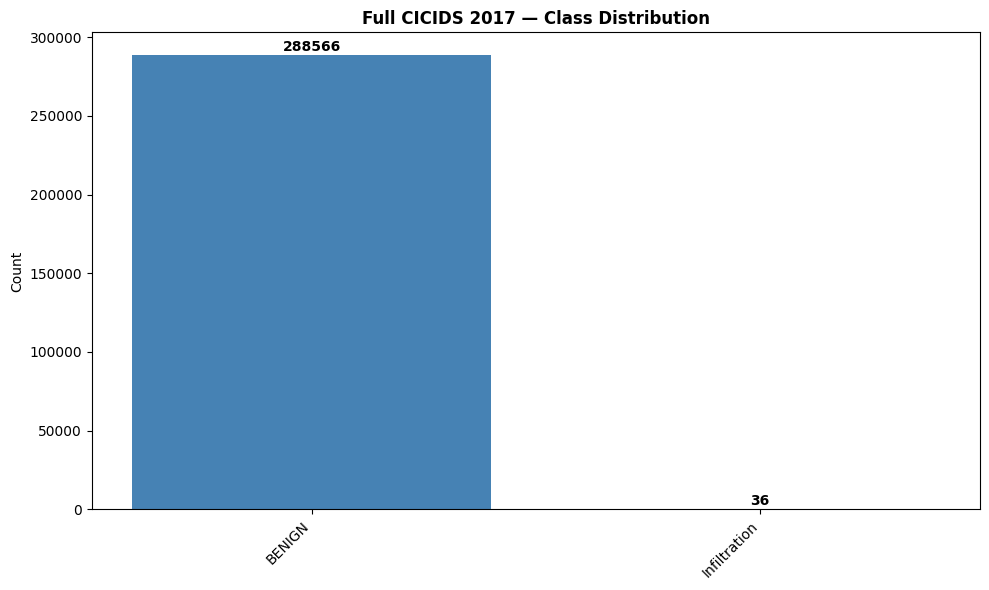

In [57]:
def preprocess_full_cicids(df: pd.DataFrame):

    # Drop non-feature columns (similar to previous, but remove Label last for encoding)
    drop_cols_base = ['Flow ID', ' Source IP', ' Source Port',
                      ' Destination IP', ' Destination Port', ' Timestamp']
    drop_cols = [c for c in drop_cols_base if c in df.columns]

    # Make a copy to avoid SettingWithCopyWarning
    df_processed = df.copy()

    # Encode labels before dropping the 'Label' column
    le = LabelEncoder()
    # Handle potential NaN in 'Label' column by filling with a placeholder or dropping
    df_processed['Label'] = df_processed['Label'].fillna('UNKNOWN_ATTACK')
    y_encoded = le.fit_transform(df_processed['Label'])

    # Now drop the original label and other non-feature columns
    X = df_processed.drop(columns=drop_cols + ['Label'], errors='ignore')

    # Keep only numeric columns
    X = X.select_dtypes(include=[np.number])

    # Replace Inf and NaN
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)

    feature_names = X.columns.tolist()

    # Standardise
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32)

    return X_scaled, y_encoded, feature_names, le

# Apply preprocessing to the full dataset
X_full_cicids, y_full_cicids_encoded, full_feature_names, cicids_label_encoder = preprocess_full_cicids(full_cicids_df)
N_FULL_FEATURES = X_full_cicids.shape[1]

print(f'\nPreprocessed Full CICIDS dataset:')
print(f'Feature dimensions : {N_FULL_FEATURES}')
print(f'Class balance (encoded):')
for i, count in enumerate(np.unique(y_full_cicids_encoded, return_counts=True)[1]):
    print(f'{cicids_label_encoder.inverse_transform([i])[0]}: {count}')

# Plot class distribution for the full dataset
fig, ax = plt.subplots(figsize=(10, 6))
classes, counts = np.unique(y_full_cicids_encoded, return_counts=True)
class_names = cicids_label_encoder.inverse_transform(classes)
ax.bar(class_names, counts, color='steelblue')
ax.set_title('Full CICIDS 2017 — Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(counts):
    ax.text(i, v + max(counts)*0.01, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('full_cicids_class_dist.png', dpi=150)
plt.show()



Training Tabular GAN on Full CICIDS traffic...
Starting Tabular GAN training for 50 epochs...
Epoch [1/50], D Loss: 0.9206, G Loss: 1.2929
Epoch [10/50], D Loss: 0.6602, G Loss: 2.0889
Epoch [20/50], D Loss: 0.4516, G Loss: 4.2950
Epoch [30/50], D Loss: 0.3463, G Loss: 5.2494
Epoch [40/50], D Loss: 0.3378, G Loss: 5.8932
Epoch [50/50], D Loss: 0.3328, G Loss: 6.2481
Tabular GAN training complete!


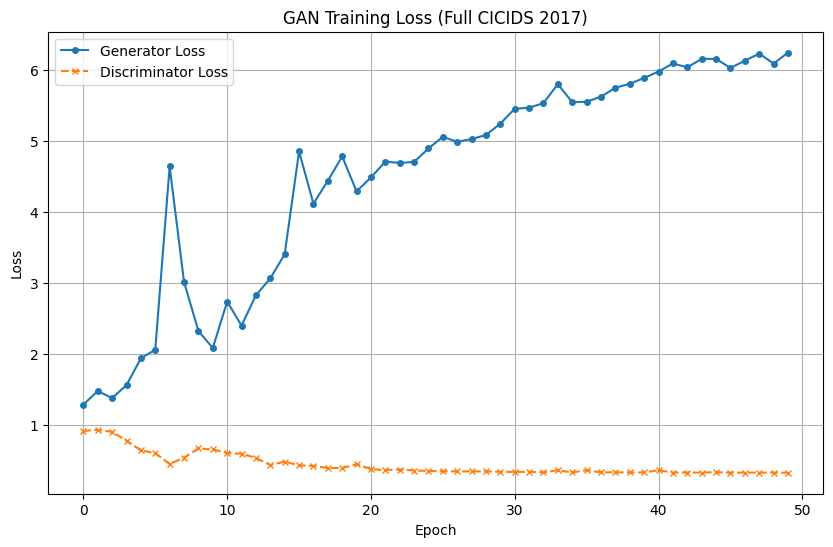

In [62]:
# Train a new Tabular GAN for the full dataset

print('\nTraining Tabular GAN on Full CICIDS traffic...')

# Convert X_full_cicids to a PyTorch tensor
X_full_cicids_tensor = torch.from_numpy(X_full_cicids).float()

G_full_cicids, g_loss_full_cicids, d_loss_full_cicids = train_tabular_gan(
    X=X_full_cicids_tensor, noise_dim=64, n_epochs=50, batch_size=512, lr=1e-4, device=device
)

plt.figure(figsize=(10,6))
plt.plot(g_loss_full_cicids, label="Generator Loss", linestyle='-', marker='o', markersize=4)
plt.plot(d_loss_full_cicids, label="Discriminator Loss", linestyle='--', marker='x', markersize=4)
plt.title("GAN Training Loss (Full CICIDS 2017)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Evaluation of Synthetic Data Alignment for Full CICIDS (PCA & t-SNE)


In [65]:
        noise_full = torch.randn(N_SAMPLES, LATENT_DIM_CICIDS).to(device)


### Quantitative Evaluation: Mean Squared Error (MSE) of Feature Means for Full CICIDS



In [67]:
G_full_cicids.eval()

with torch.no_grad():
    noise_full = torch.randn(N_SAMPLES, LATENT_DIM_CICIDS).to(device)
    fake_data_full = G_full_cicids(noise_full).cpu().numpy()

if isinstance(X_full_cicids, torch.Tensor):
    X_full_cicids_np = X_full_cicids.cpu().numpy()
else:
    X_full_cicids_np = X_full_cicids

num_samples_for_comparison = min(N_SAMPLES, X_full_cicids_np.shape[0])

real_indices_full = np.random.choice(X_full_cicids_np.shape[0], num_samples_for_comparison, replace=False)
real_data_full = X_full_cicids_np[real_indices_full]

real_data_mean_full = np.mean(real_data_full, axis=0)
fake_data_mean_full = np.mean(fake_data_full, axis=0)

mse_full = np.mean((real_data_mean_full - fake_data_mean_full)**2)

print(f"Mean Squared Error between real and synthetic feature means (Full CICIDS): {mse_full:.4f}")

Mean Squared Error between real and synthetic feature means (Full CICIDS): 0.0322


### Discussion on GAN Performance with Full CICIDS Dataset



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


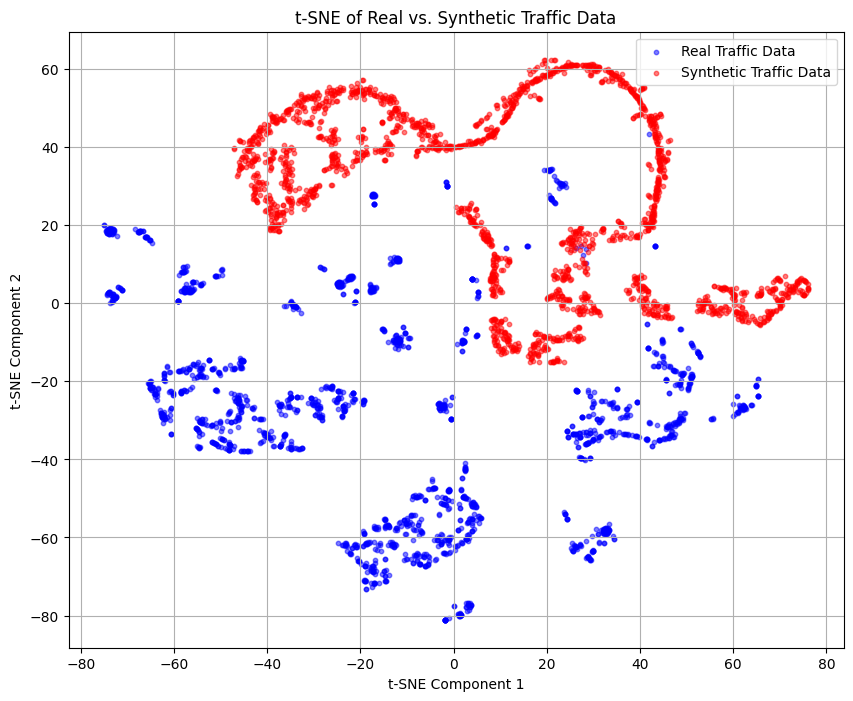

In [70]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Generate synthetic samples using the trained generator
G_full_cicids.eval() # Set generator to evaluation mode
num_tsne_samples = 2000 # Use a smaller number of samples for t-SNE due to computational cost
noise = torch.randn(num_tsne_samples, LATENT_DIM_CICIDS).to(device)
synthetic_samples_tsne = G_full_cicids(noise).detach().cpu().numpy()

# Prepare real data subset for t-SNE
# Use a subset of real data equal to the number of synthetic samples for balanced comparison
num_real_samples_tsne = min(num_tsne_samples, X_full_cicids_tensor.shape[0])
real_samples_subset_tsne = X_full_cicids_tensor[:num_real_samples_tsne].cpu().numpy()

# Combine real and synthetic data for t-SNE
combined_data_tsne = np.vstack((real_samples_subset_tsne, synthetic_samples_tsne))

# Apply t-SNE (adjust perplexity and n_iter as needed)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, learning_rate=200)
reduced_data_tsne = tsne.fit_transform(combined_data_tsne)

# Split back into real and synthetic for plotting
real_tsne = reduced_data_tsne[:num_real_samples_tsne]
synthetic_tsne = reduced_data_tsne[num_real_samples_tsne:]

# Plot t-SNE results
plt.figure(figsize=(10, 8))
plt.scatter(real_tsne[:, 0], real_tsne[:, 1], alpha=0.5, s=10, label='Real Traffic Data', color='blue')
plt.scatter(synthetic_tsne[:, 0], synthetic_tsne[:, 1], alpha=0.5, s=10, label='Synthetic Traffic Data', color='red')
plt.title('t-SNE of Real vs. Synthetic Traffic Data')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()
plt.grid(True)
plt.show()

part 2.3  Creative AI – QuickDraw 'Pizza' Subset

In [71]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.linalg import sqrtm
from tqdm.notebook import tqdm

Download complete.
Pizza dataset shape: (130371, 784)
Using first 20,000 samples for training.


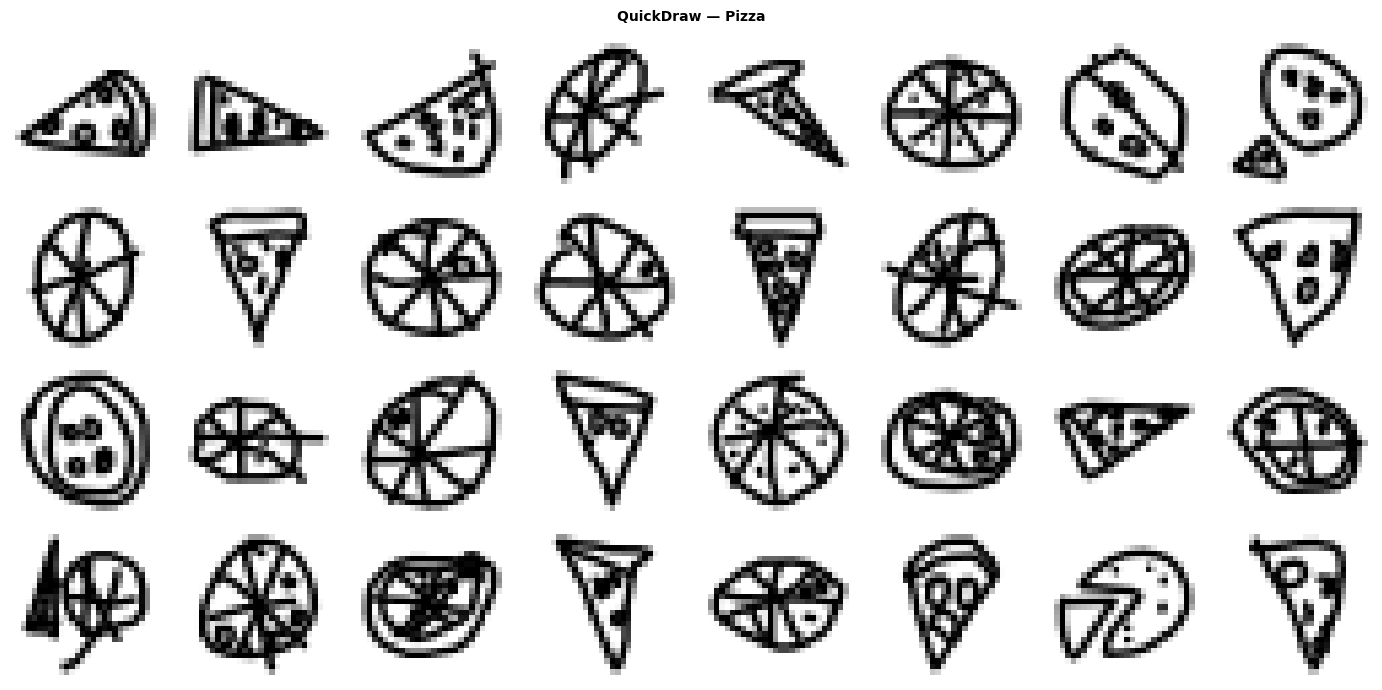

In [72]:
import urllib.request
import os
import numpy as np
import matplotlib.pyplot as plt

QUICKDRAW_URL  = 'https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/pizza.npy'
QUICKDRAW_FILE = 'pizza.npy'

if not os.path.exists(QUICKDRAW_FILE):
    print('Downloading QuickDraw pizza dataset...')
    urllib.request.urlretrieve(QUICKDRAW_URL, QUICKDRAW_FILE)
    print('Download complete.')

pizza_raw = np.load(QUICKDRAW_FILE)   # shape: (N, 784), values 0-255
print(f'Pizza dataset shape: {pizza_raw.shape}')
print(f'Using first 20,000 samples for training.')

# ── Visualise sample sketches ─────────────────────────────────────────────────
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(pizza_raw[i].reshape(28, 28), cmap='gray_r')  # invert: white bg → black bg
    ax.axis('off')
fig.suptitle('QuickDraw — Pizza', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('pizza_real_samples.png', dpi=150, bbox_inches='tight')
plt.show()

Starting DCGAN training for QuickDraw Pizza...
Epoch [0/50] Loss_D: 0.4748 Loss_G: 3.1996
Epoch [5/50] Loss_D: 0.1100 Loss_G: 5.0340
Epoch [10/50] Loss_D: 0.0254 Loss_G: 5.0681
Epoch [15/50] Loss_D: 0.0701 Loss_G: 5.5913
Epoch [20/50] Loss_D: 0.3605 Loss_G: 3.9082
Epoch [25/50] Loss_D: 0.1323 Loss_G: 9.4837
Epoch [30/50] Loss_D: 0.0318 Loss_G: 5.3202
Epoch [35/50] Loss_D: 4.5292 Loss_G: 0.6430
Epoch [40/50] Loss_D: 0.1109 Loss_G: 4.7703
Epoch [45/50] Loss_D: 0.0164 Loss_G: 6.0035
Epoch [49/50] Loss_D: 0.0115 Loss_G: 6.9263
DCGAN training for QuickDraw Pizza complete!


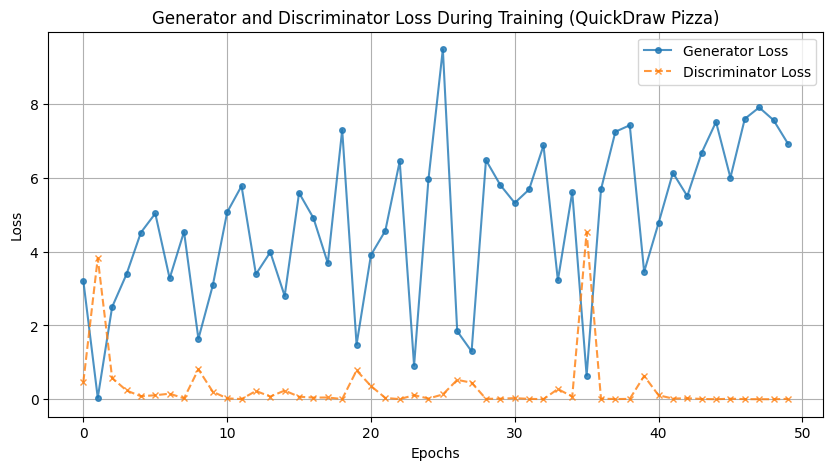

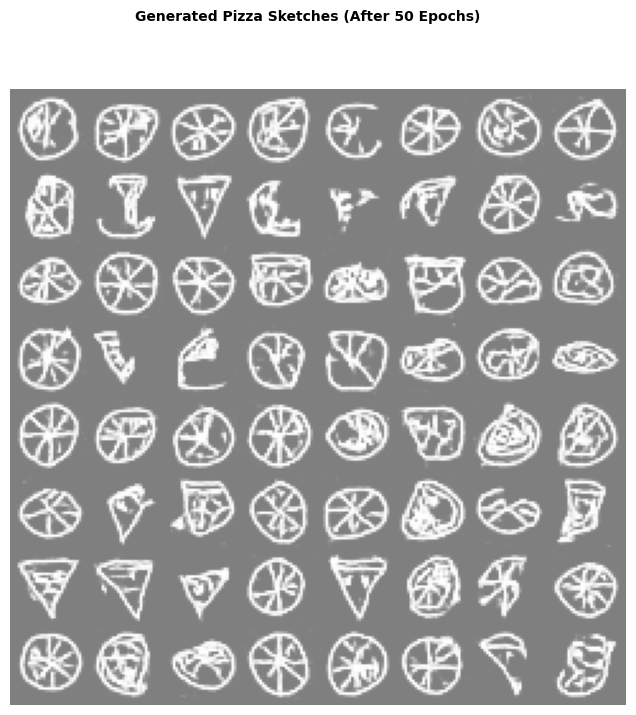

In [73]:
# Preprocessing the data
pizza_data = pizza_raw[:20000] # Use a subset for faster training
pizza_data = pizza_data.reshape(-1, 1, 28, 28) # Reshape to (N, C, H, W)
pizza_data = torch.tensor(pizza_data, dtype=torch.float32) # Convert to torch tensor
pizza_data = (pizza_data - 127.5) / 127.5  # Normalize to [-1, 1]

# Create a DataLoader
batch_size = 64
dataset = TensorDataset(pizza_data)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Generator Architecture (DCGAN for 28x28 grayscale images)
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            # Input: (latent_dim, 1, 1)
            nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0, bias=False), # Output: (256, 4, 4)
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 3, 2, 1, bias=False), # Output: (128, 7, 7)
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False), # Output: (64, 14, 14)
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),  # Output: (1, 28, 28)
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

# Discriminator Architecture (DCGAN for 28x28 grayscale images)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Input: (1, 28, 28)
            nn.Conv2d(1, 64, 4, 2, 1, bias=False), # Output: (64, 14, 14)
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False), # Output: (128, 7, 7)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 3, 2, 1, bias=False), # Output: (256, 4, 4)
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False), # Output: (1, 1, 1)
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Hyperparameters
latent_dim = 100
num_epochs = 50
lr = 0.0002
betas = (0.5, 0.999)

# Instantiate Generator and Discriminator
G_pizza = Generator(latent_dim).to(device)
D_pizza = Discriminator().to(device)

# Loss function and optimizers
criterion = nn.BCELoss()
optimizer_G_pizza = optim.Adam(G_pizza.parameters(), lr=lr, betas=betas)
optimizer_D_pizza = optim.Adam(D_pizza.parameters(), lr=lr, betas=betas)

# Training Loop
g_losses_pizza = []
d_losses_pizza = []
img_list_pizza = []

print("Starting DCGAN training for QuickDraw Pizza...")
for epoch in range(num_epochs):
    for i, (real_imgs,) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        # Create labels for real and fake images
        # Changed from (b_size, 1) to (b_size,) to match discriminator output .view(-1)
        real_labels = torch.full((b_size,), 1.0, dtype=torch.float, device=device)
        fake_labels = torch.full((b_size,), 0.0, dtype=torch.float, device=device)

        # --- Train Discriminator ---
        D_pizza.zero_grad()
        # Train with real images
        output_real = D_pizza(real_imgs).view(-1)
        errD_real = criterion(output_real, real_labels)
        errD_real.backward()

        # Train with fake images
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        fake_imgs = G_pizza(noise)
        output_fake = D_pizza(fake_imgs.detach()).view(-1)
        errD_fake = criterion(output_fake, fake_labels)
        errD_fake.backward()

        errD = errD_real + errD_fake
        optimizer_D_pizza.step()

        # --- Train Generator ---
        G_pizza.zero_grad()
        output_gen = D_pizza(fake_imgs).view(-1)
        errG = criterion(output_gen, real_labels) # Generator wants fake images to be classified as real
        errG.backward()
        optimizer_G_pizza.step()

    # Save Losses for plotting later
    g_losses_pizza.append(errG.item())
    d_losses_pizza.append(errD.item())

    # Output training stats
    if epoch % 5 == 0 or epoch == num_epochs - 1:
        print(f'Epoch [{epoch}/{num_epochs}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f}')
        # Generate and save images from generator
        with torch.no_grad():
            fixed_noise = torch.randn(64, latent_dim, 1, 1, device=device)
            fake = G_pizza(fixed_noise).detach().cpu()
            img_list_pizza.append(vutils.make_grid(fake, padding=2, normalize=True))

print("DCGAN training for QuickDraw Pizza complete!")

# Plot the training losses
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training (QuickDraw Pizza)")
plt.plot(g_losses_pizza, label="Generator Loss", linestyle='-', marker='o', markersize=4, alpha=0.8)
plt.plot(d_losses_pizza, label="Discriminator Loss", linestyle='--', marker='x', markersize=4, alpha=0.8)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True) # Add grid for better readability
plt.show()

# Visualize some generated images (the last grid saved)
fig = plt.figure(figsize=(8,8))
plt.axis("off")
if img_list_pizza:
    # Get the last generated grid, denormalize, and transpose for plotting
    last_grid = img_list_pizza[-1]
    img_to_display = np.transpose(last_grid.numpy(), (1, 2, 0))
    img_to_display = (img_to_display + 1) / 2 # Denormalize from [-1, 1] to [0, 1]
    plt.imshow(img_to_display)
plt.suptitle(f'Generated Pizza Sketches (After {num_epochs} Epochs)', fontweight='bold', fontsize=10)
plt.show()

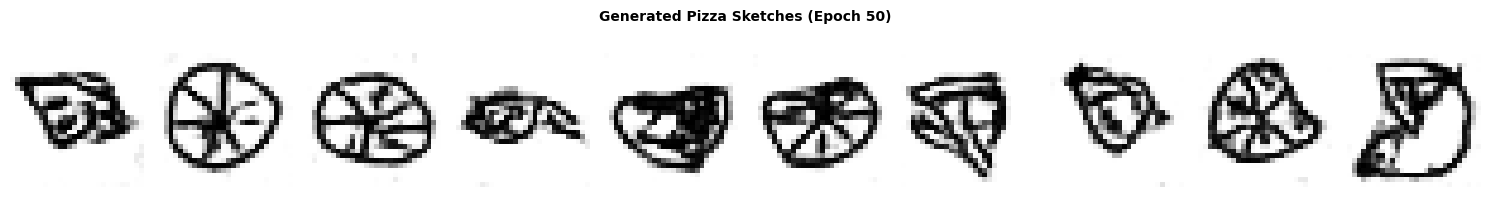

In [74]:
def display_generated_pizza_images(generator, latent_dim, n=10):
    generator.eval()
    # Generate random noise vectors
    z = torch.randn(n, latent_dim, 1, 1).to(device)
    # Generate images
    fake_images = generator(z).detach().cpu()

    fig, axes = plt.subplots(1, n, figsize=(15, 2))
    for i in range(n):
        # Denormalize pixel values from [-1, 1] to [0, 1] and remove the channel dimension
        img = fake_images[i].squeeze() # shape is (H, W)
        img = (img + 1) / 2 # Denormalization step
        axes[i].imshow(img, cmap='gray_r') # Use gray_r for black sketches on white background
        axes[i].axis('off')
    fig.suptitle(f'Generated Pizza Sketches (Epoch {num_epochs})', fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.show()

# Display 10 newly generated pizza sketches
display_generated_pizza_images(G_pizza, latent_dim, n=10)

### Extension: Generate QuickDraw 'House' Sketches

Download complete.
House dataset shape: (135420, 784)
Using first 20,000 samples for training.


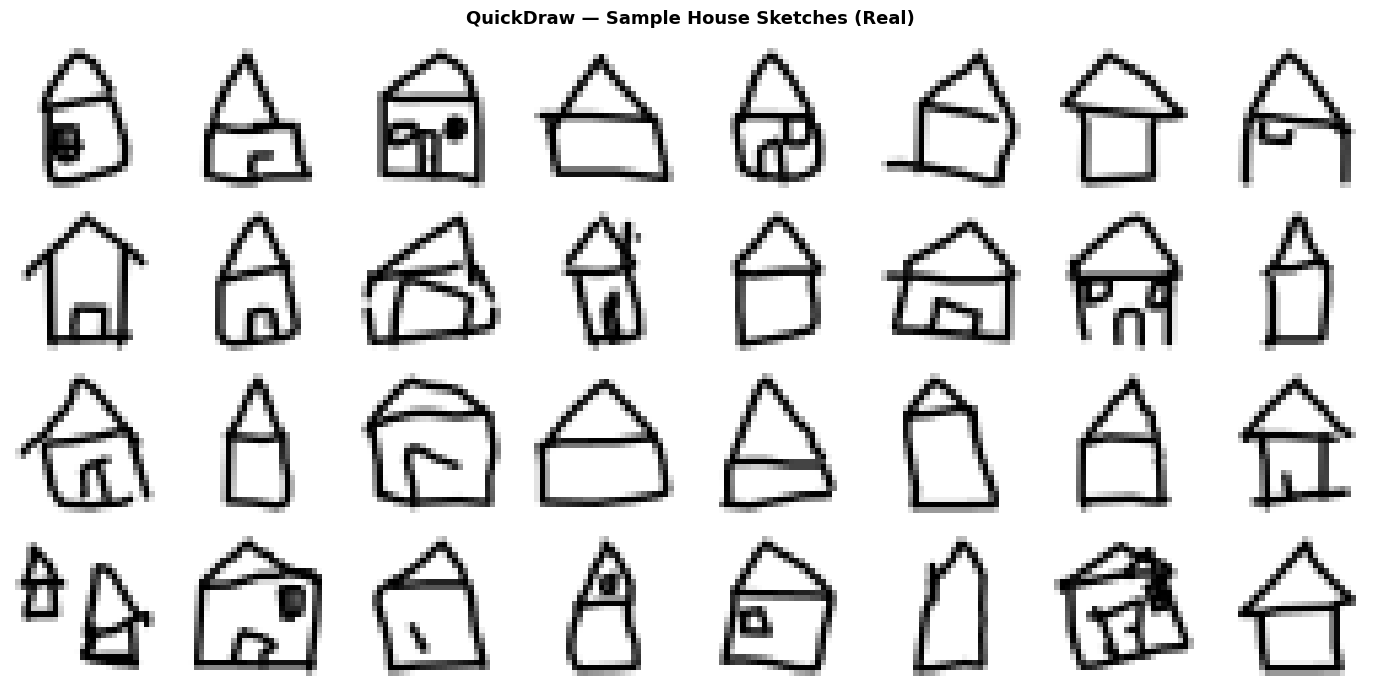

In [75]:
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
# Download the QuickDraw 'house' dataset
HOUSE_URL = 'https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/house.npy'
HOUSE_FILE = 'house.npy'

if not os.path.exists(HOUSE_FILE):
    print('Downloading QuickDraw house dataset...')
    urllib.request.urlretrieve(HOUSE_URL, HOUSE_FILE)
    print('Download complete.')

house_raw = np.load(HOUSE_FILE)   # shape: (N, 784), values 0-255
print(f'House dataset shape: {house_raw.shape}')
print(f'Using first 20,000 samples for training.')

# Visualize sample sketches
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(house_raw[i].reshape(28, 28), cmap='gray_r')  # invert: white bg → black bg
    ax.axis('off')
fig.suptitle('QuickDraw — Sample House Sketches (Real)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('house_real_samples.png', dpi=150, bbox_inches='tight')
plt.show()

In [76]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Preprocessing the house data
house_data = house_raw[:20000] # Use a subset for faster training
house_data = house_data.reshape(-1, 1, 28, 28) # Reshape to (N, C, H, W)
house_data = torch.tensor(house_data, dtype=torch.float32) # Convert to torch tensor
house_data = (house_data - 127.5) / 127.5  # Normalize to [-1, 1]

# Create a DataLoader for house data
batch_size_house = 64
house_dataset = TensorDataset(house_data)
house_dataloader = DataLoader(house_dataset, batch_size=batch_size_house, shuffle=True)

In [77]:
import torch.nn as nn

# Generator Architecture (DCGAN for 28x28 grayscale images)
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            # Input: (latent_dim, 1, 1)
            nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0, bias=False), # Output: (256, 4, 4)
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 3, 2, 1, bias=False), # Output: (128, 7, 7)
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False), # Output: (64, 14, 14)
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),  # Output: (1, 28, 28)
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

# Discriminator Architecture (DCGAN for 28x28 grayscale images)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Input: (1, 28, 28)
            nn.Conv2d(1, 64, 4, 2, 1, bias=False), # Output: (64, 14, 14)
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False), # Output: (128, 7, 7)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 3, 2, 1, bias=False), # Output: (256, 4, 4)
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False), # Output: (1, 1, 1)
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [78]:
import torch.optim as optim
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
latent_dim = 100
num_epochs = 50 # Add num_epochs here
lr = 0.0002
betas = (0.5, 0.999)

# Instantiate new Generator and Discriminator for houses (reusing class definitions)
G_house = Generator(latent_dim).to(device)
D_house = Discriminator().to(device);

criterion = nn.BCELoss() # Define criterion here for the house GAN

# Loss function and optimizers for house GAN
optimizer_G_house = optim.Adam(G_house.parameters(), lr=lr, betas=betas)
optimizer_D_house = optim.Adam(D_house.parameters(), lr=lr, betas=betas)

In [79]:
# Training Loop for House GAN
g_losses_house = []
d_losses_house = []
img_list_house = []

print("Starting DCGAN training for QuickDraw House...")
for epoch in range(num_epochs):
    for i, (real_imgs,) in enumerate(house_dataloader):
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        # Create labels for real and fake images
        real_labels = torch.full((b_size,), 1.0, dtype=torch.float, device=device)
        fake_labels = torch.full((b_size,), 0.0, dtype=torch.float, device=device)

        # --- Train Discriminator ---
        D_house.zero_grad()
        # Train with real images
        output_real = D_house(real_imgs).view(-1)
        errD_real = criterion(output_real, real_labels)
        errD_real.backward()

        # Train with fake images
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        fake_imgs = G_house(noise)
        output_fake = D_house(fake_imgs.detach()).view(-1)
        errD_fake = criterion(output_fake, fake_labels)
        errD_fake.backward()

        errD = errD_real + errD_fake
        optimizer_D_house.step()

        # --- Train Generator ---
        G_house.zero_grad()
        output_gen = D_house(fake_imgs).view(-1)
        errG = criterion(output_gen, real_labels) # Generator wants fake images to be classified as real
        errG.backward()
        optimizer_G_house.step()

    # Save Losses for plotting later
    g_losses_house.append(errG.item())
    d_losses_house.append(errD.item())

    # Output training stats
    if epoch % 5 == 0 or epoch == num_epochs - 1:
        print(f'Epoch [{epoch}/{num_epochs}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f}')
        # Generate and save images from generator
        with torch.no_grad():
            fixed_noise_house = torch.randn(64, latent_dim, 1, 1, device=device)
            fake_house = G_house(fixed_noise_house).detach().cpu()
            img_list_house.append(vutils.make_grid(fake_house, padding=2, normalize=True))

print("DCGAN training for QuickDraw House complete!")

Starting DCGAN training for QuickDraw House...
Epoch [0/50] Loss_D: 0.1953 Loss_G: 3.5026
Epoch [5/50] Loss_D: 0.0236 Loss_G: 5.4066
Epoch [10/50] Loss_D: 0.2571 Loss_G: 1.3695
Epoch [15/50] Loss_D: 0.1501 Loss_G: 3.9311
Epoch [20/50] Loss_D: 0.0439 Loss_G: 5.5384
Epoch [25/50] Loss_D: 0.0212 Loss_G: 5.6657
Epoch [30/50] Loss_D: 0.0141 Loss_G: 7.2951
Epoch [35/50] Loss_D: 0.0242 Loss_G: 6.1576
Epoch [40/50] Loss_D: 0.0539 Loss_G: 4.6304
Epoch [45/50] Loss_D: 0.0173 Loss_G: 6.1133
Epoch [49/50] Loss_D: 0.0133 Loss_G: 5.8334
DCGAN training for QuickDraw House complete!


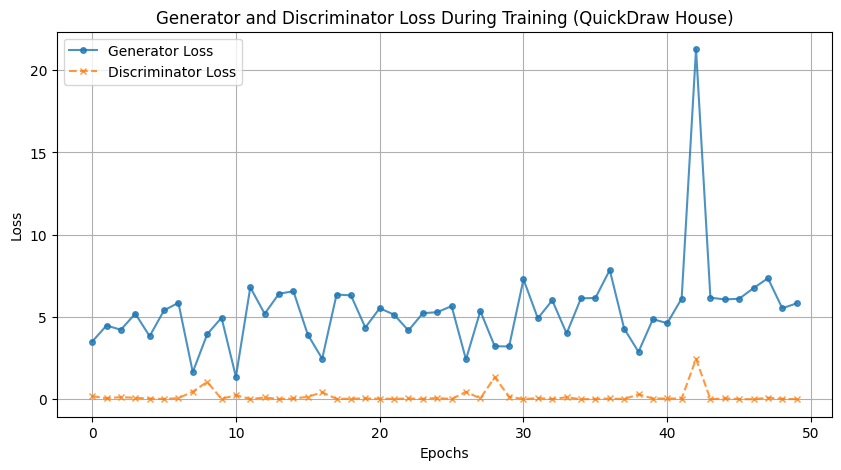

In [80]:
# Plot the training losses for House GAN
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training (QuickDraw House)")
plt.plot(g_losses_house, label="Generator Loss", linestyle='-', marker='o', markersize=4, alpha=0.8)
plt.plot(d_losses_house, label="Discriminator Loss", linestyle='--', marker='x', markersize=4, alpha=0.8)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True) # Add grid for better readability
plt.show()

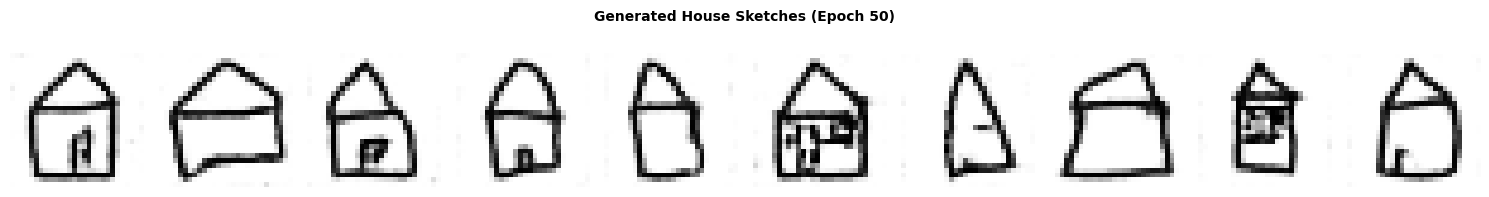

In [81]:
def display_generated_house_images(generator, latent_dim, n=10):
    generator.eval()
    # Generate random noise vectors
    z = torch.randn(n, latent_dim, 1, 1).to(device)
    # Generate images
    fake_images = generator(z).detach().cpu()

    fig, axes = plt.subplots(1, n, figsize=(15, 2))
    for i in range(n):
        # Denormalize pixel values from [-1, 1] to [0, 1] and remove the channel dimension
        img = fake_images[i].squeeze() # shape is (H, W)
        img = (img + 1) / 2 # Denormalization step
        axes[i].imshow(img, cmap='gray_r') # Use gray_r for black sketches on white background
        axes[i].axis('off')
    fig.suptitle(f'Generated House Sketches (Epoch {num_epochs})', fontweight='bold', fontsize=10)
    plt.tight_layout()
    plt.show()

# Display 10 newly generated house sketches
display_generated_house_images(G_house, latent_dim, n=10)

### Comparison of Generated vs. Real QuickDraw Images

#### Pizza Sketches

##### Real Pizza Sketches

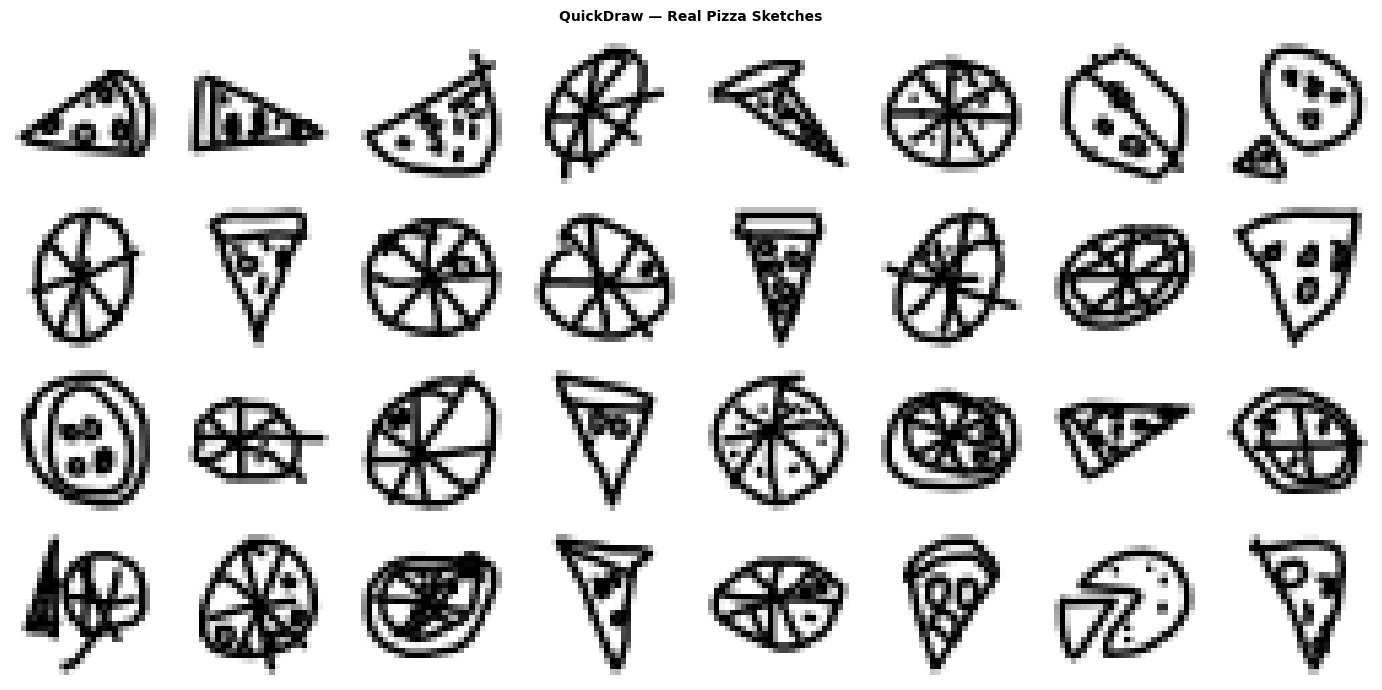

In [82]:
# Visualize sample real pizza sketches
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(pizza_raw[i].reshape(28, 28), cmap='gray_r')
    ax.axis('off')
fig.suptitle('QuickDraw — Real Pizza Sketches', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

##### Generated Pizza Sketches

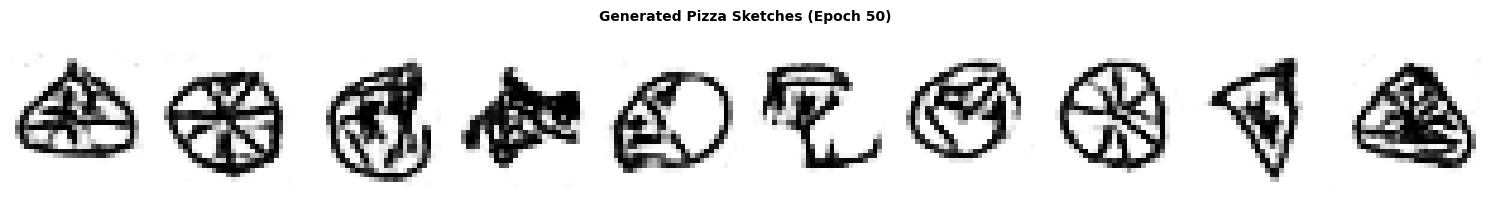

In [83]:
# Display newly generated pizza sketches
display_generated_pizza_images(G_pizza, latent_dim, n=10)

#### House Sketches

##### Real House Sketches

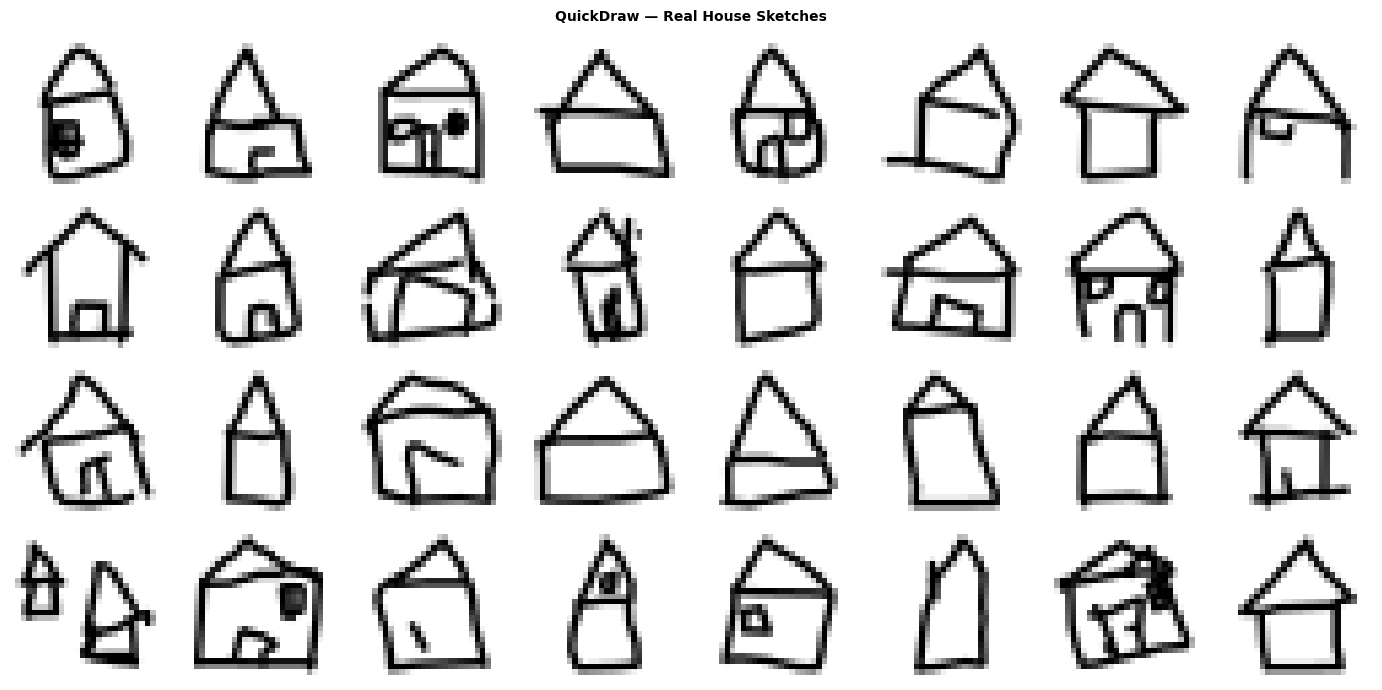

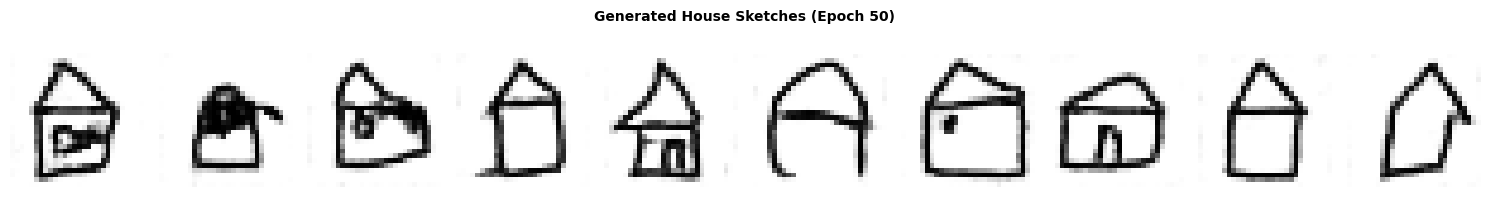

In [84]:
# Visualize sample real house sketches
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(house_raw[i].reshape(28, 28), cmap='gray_r')
    ax.axis('off')
fig.suptitle('QuickDraw — Real House Sketches', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()
# Display newly generated house sketches
display_generated_house_images(G_house, latent_dim, n=10)

##### Generated House Sketches

### Quantitative Evaluation: Frechet Inception Distance (FID)

In [85]:
import numpy as np
from scipy.linalg import sqrtm

def calculate_fid(real, fake):
    mu1, sigma1 = real.mean(axis=0), np.cov(real, rowvar=False)
    mu2, sigma2 = fake.mean(axis=0), np.cov(fake, rowvar=False)

    diff = mu1 - mu2
    # Ensure covmean is real by taking the real part
    covmean = sqrtm(sigma1.dot(sigma2))

    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2*covmean)
    return np.real(fid)

def prepare_fid_data(generator, real_data_tensor, latent_dim, num_samples, device):
    generator.eval()
    # Generate fake images
    z = torch.randn(num_samples, latent_dim, 1, 1).to(device)
    fake_images = generator(z).detach().cpu().numpy()
    fake_images = fake_images.reshape(num_samples, -1) # Flatten to (N, 784)

    # Prepare real images
    real_images = real_data_tensor[:num_samples].cpu().numpy()
    real_images = real_images.reshape(num_samples, -1) # Flatten to (N, 784)

    return real_images, fake_images

# --- Calculate FID for Pizza ---
num_fid_samples = min(pizza_data.shape[0], 10000) # Use up to 10000 samples for FID
pizza_real_fid_data, pizza_fake_fid_data = prepare_fid_data(G_pizza, pizza_data, latent_dim, num_fid_samples, device)
fid_pizza = calculate_fid(pizza_real_fid_data, pizza_fake_fid_data)
print(f"FID Score for Pizza: {fid_pizza:.4f}")

# --- Calculate FID for House ---
num_fid_samples = min(house_data.shape[0], 10000) # Use up to 10000 samples for FID
house_real_fid_data, house_fake_fid_data = prepare_fid_data(G_house, house_data, latent_dim, num_fid_samples, device)
fid_house = calculate_fid(house_real_fid_data, house_fake_fid_data)
print(f"FID Score for House: {fid_house:.4f}")

FID Score for Pizza: 25.6790
FID Score for House: 12.6183
